
# Regression Modelling of Air Quality Using Global Meteorological Data
**Group:** 71  \
**Team:** Rahul Sanju · Rahul Satheesan Nair · Sooryakiran Vinod · Nitin Sunil Thomas

This notebook builds and evaluates regression models that predict fine particulate matter concentration (PM2.5, µg/m³) from global meteorological data and co-emitted pollutants.
We follow a CRISP-DM-style workflow: business understanding, data understanding, data preparation, modelling, evaluation, and a deployment-style export of trained models.

## Step 1 - Imports & Setup

In [1]:
!pip install xgboost shap statsmodels mlxtend -q
import warnings
warnings.filterwarnings('ignore')
print(" Packages installed")

 Packages installed


Before running the notebook, we install the three external libraries not included in the default Colab environment. `xgboost` provides the gradient boosting model used as our best-performing regressor. `shap` enables post-hoc explainability by computing each feature's contribution to individual predictions. `statsmodels` provides OLS diagnostics, the Breusch-Pagan heteroscedasticity test, and VIF computation. Warnings are suppressed globally to keep output clean during long training runs.

## Step 2 - Loading the Dataset

In [2]:
import os

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

DATA_PATH = "/content/GlobalWeatherRepository.csv"
print(f"DATA_PATH: {DATA_PATH}")

Output directory: /content/outputs
DATA_PATH: /content/GlobalWeatherRepository.csv


We create a local output directory (`/content/outputs`) where all saved figures, model files, and results CSVs will be written. This keeps the notebook's file outputs organised and makes them easy to download at the end. The directory is created with `exist_ok=True`, so re-running this cell does not raise an error if the folder already exists. Two options are provided for loading the dataset  via the Kaggle API or by direct file upload.

##  Step 3 - Imports & Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, f_oneway
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.impute import SimpleImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

from xgboost import XGBRegressor
import shap
import joblib
import math

# Constants
TARGET_COL   = "air_quality_PM2.5"
RANDOM_STATE = 42
FIG_DPI      = 130

METEO_FEATURES = [
    "temperature_celsius", "humidity", "wind_kph", "wind_degree",
    "pressure_mb", "precip_mm", "feelslike_celsius", "visibility_km",
    "uv_index", "cloud", "gust_kph", "dewpoint_celsius",
]

# PM10 excluded: highly correlated with PM2.5 (r≈0.65, shared emission sources).
# Co-occurrence ≠ causation — PM10 and PM2.5 are co-produced, not causally linked.
# Keeping PM10 would inflate R² via spurious correlation, not real meteorological signal.
POLLUTANT_FEATURES = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    # air_quality_PM10 intentionally excluded — see rationale above
    # air_quality_PM2.5 is the TARGET
]

def save_fig(name):
    plt.savefig(f"{OUTPUT_DIR}/{name}", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

print(" Imports & configuration complete")
print(f"   Target: {TARGET_COL}")
print(f"   Meteo features: {len(METEO_FEATURES)}")
print(f"   Pollutant features (excl. PM10 & PM2.5): {len(POLLUTANT_FEATURES)}")

 Imports & configuration complete
   Target: air_quality_PM2.5
   Meteo features: 12
   Pollutant features (excl. PM10 & PM2.5): 4


All libraries required throughout the project are imported here and grouped by purpose. `numpy` and `pandas` handle numerical computation and tabular data. `matplotlib` and `seaborn` are used for all visualisations. `scipy.stats` provides Pearson correlation, one-way ANOVA, and the Mahalanobis distance for multivariate outlier detection. Scikit-learn supplies preprocessing tools (`StandardScaler`, `LabelEncoder`, `SimpleImputer`), model classes (Linear, Ridge, Lasso, Random Forest, SVR), and evaluation utilities. `statsmodels` is used for OLS diagnostics, VIF computation, and the Breusch-Pagan test. `XGBRegressor` and `shap` handle the best-performing model and its explainability. Three project-wide constants are also defined: `TARGET_COL` sets PM2.5 as the regression target, `RANDOM_STATE = 42` ensures all random operations are reproducible, and `FIG_DPI = 130` controls figure resolution.

 ##  Step 4 - Load Dataset & Fix Sensor Errors


PM2.5 is chosen as the target variable because it directly reflects air pollution levels and is influenced by real environmental factors. For example, wind helps spread particles away, rain removes them from the air, temperature inversions can trap pollution near the ground, and humidity affects how particles behave. This makes it suitable for a regression model with meaningful cause-and-effect relationships. In contrast, the US-EPA AQI is simply calculated from PM2.5 using a fixed scale, so predicting AQI while using PM2.5 as an input doesn’t add real value. According to WHO guidelines, safe PM2.5 levels are below 15 μg/m³ annually, while levels around 75 μg/m³ over 24 hours are considered hazardous.

In [4]:
# Load dataset & fix bad sensor values
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Original shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Fix sentinel bad sensor values (negative values are physically impossible)
bad_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Sulphur_dioxide',
            'air_quality_PM10', 'air_quality_PM2.5']
for col in bad_cols:
    if col in df_raw.columns:
        n_bad = (df_raw[col] < 0).sum()
        df_raw[col] = df_raw[col].where(df_raw[col] >= 0, np.nan)
        if n_bad > 0:
            print(f"  Fixed {n_bad:,} negative sensor values in {col}")

# Fix physically impossible wind speed (cap at 300 kph — hurricane maximum)
for col in ['wind_kph', 'gust_kph']:
    if col in df_raw.columns:
        n_bad = (df_raw[col] > 300).sum()
        df_raw[col] = df_raw[col].where(df_raw[col] <= 300, np.nan)
        if n_bad > 0:
            print(f"  Fixed {n_bad:,} impossible wind values in {col}")
# FIX: Cap pressure_mb at 1100 mb — Earth's highest recorded SLP is ~1084 mb.
# Values like 3006 mb in the raw data are physically impossible sensor errors.
# Without this cap, pressure_mb has skewness=107 and kurtosis=19,942 (Cell 30),
# which would distort IQR outlier detection and model training.
if 'pressure_mb' in df_raw.columns:
    PRESSURE_MAX = 1100  # mb — well above any natural atmospheric pressure
    n_bad_p = (df_raw['pressure_mb'] > PRESSURE_MAX).sum()
    df_raw['pressure_mb'] = df_raw['pressure_mb'].where(
        df_raw['pressure_mb'] <= PRESSURE_MAX, np.nan
    )
    if n_bad_p > 0:
        print(f"  Fixed {n_bad_p:,} impossible pressure values in pressure_mb "
              f"(>{PRESSURE_MAX} mb -> NaN)")
    else:
        print(f"  pressure_mb: no values above {PRESSURE_MAX} mb found")

# Note: The ~5 rows with NaN introduced above (sensor fixes) are NOT dropped here.
# They will be handled by median imputation after the train/test split (Cell 46),
# preventing any bias from systematic row removal.
print(f"Shape after sensor fix: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Original shape: 120,432 rows × 41 columns
  Fixed 1 negative sensor values in air_quality_Carbon_Monoxide
  Fixed 1 negative sensor values in air_quality_Sulphur_dioxide
  Fixed 2 negative sensor values in air_quality_PM10
  Fixed 1 impossible wind values in wind_kph
  Fixed 1 impossible wind values in gust_kph
  Fixed 2 impossible pressure values in pressure_mb (>1100 mb -> NaN)
Shape after sensor fix: 120,432 rows × 41 columns


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


The raw CSV is loaded and three types of physically impossible sensor readings are corrected before any analysis begins. Negative concentrations in `air_quality_Carbon_Monoxide`, `air_quality_Sulphur_dioxide`, `air_quality_PM10`, and `air_quality_PM2.5` are replaced with `NaN`, since pollutant concentrations cannot be negative (1 fix each in CO and SO₂, 2 in PM10). Wind speeds above 300 km/h in `wind_kph` and `gust_kph` are also set to `NaN`, as this threshold exceeds the strongest recorded hurricane (1 fix each). Finally, `pressure_mb` values above 1,100 mb are replaced with `NaN`  Earth's highest ever recorded pressure is ~1,084 mb, and without this fix, `pressure_mb` carries a skewness of 107 and kurtosis of 19,942, which would distort outlier detection and model training. The ~5 `NaN` values introduced are not dropped here; they are handled by median imputation after the train/test split to avoid systematic data-loss bias.


## Step 5 - Missing Data Audit & Descriptive Statistics


In [5]:
# Missing Data & Descriptive Statistics
print("=" * 60)
print("MISSING DATA AUDIT")
print("=" * 60)
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0.01]

if len(missing_nonzero) == 0:
    print("\n No missing values in any column.")
    print("   The ~6 sensor-error values replaced with NaN in Cell 9 represent")
    print("   < 0.01% of rows and are handled by median imputation after the")
    print("   train/test split. They do not appear here because their percentage")
    print("   rounds to 0.0% at 120,432 rows.")
else:
    print(f"\n{'Column':<45} {'Missing %':>10}  Mechanism")
    print("-" * 75)
    for col, pct in missing_nonzero.items():
        if pct < 5:
            mech = "MCAR — safe to impute"
        elif pct < 30:
            mech = "MAR — impute with care"
        else:
            mech = " MNAR — investigate"
        print(f"  {col:<43} {pct:>9.1f}%  -> {mech}")

print(f"\nDuplicates: {df_raw.duplicated().sum():,}")
print(f"Total rows:  {len(df_raw):,}")
print("\n Descriptive Statisticss")
all_feats = [c for c in METEO_FEATURES + POLLUTANT_FEATURES
             + ['air_quality_PM10', TARGET_COL] if c in df_raw.columns]
df_raw[all_feats].describe().T.round(3)

MISSING DATA AUDIT

 No missing values in any column.
   The ~6 sensor-error values replaced with NaN in Cell 9 represent
   < 0.01% of rows and are handled by median imputation after the
   train/test split. They do not appear here because their percentage
   rounds to 0.0% at 120,432 rows.

Duplicates: 0
Total rows:  120,432

 Descriptive Statisticss


,count,mean,std,min,25%,50%,75%,max
temperature_celsius,120432.0,21.817,9.424,-29.800,16.500,24.200,28.100,49.200
humidity,120432.0,65.867,24.049,2.000,49.000,71.000,84.000,100.000
wind_kph,120431.0,12.990,8.414,3.600,6.500,11.200,18.000,272.200
wind_degree,120432.0,169.529,103.327,1.000,81.000,162.000,256.000,360.000
pressure_mb,120430.0,1014.080,6.961,947.000,1010.000,1014.000,1018.000,1080.000
precip_mm,120432.0,0.138,0.577,0.000,0.000,0.000,0.030,42.240
visibility_km,120432.0,9.539,2.648,0.000,10.000,10.000,10.000,32.000
uv_index,120432.0,3.503,3.573,0.000,0.200,2.300,6.000,16.300
cloud,120432.0,39.916,34.020,0.000,0.000,30.000,75.000,100.000
gust_kph,120431.0,18.285,11.214,3.600,10.400,15.500,24.300,279.400


The dataset is audited for missing values across all columns. The audit confirms no columns exceed the 0.01% threshold the ~6 `NaN` values introduced during sensor fixes in the previous cell represent less than 0.01% of the 120,432 rows and do not appear here as their percentage rounds to 0.0%. There are also 0 duplicate rows, confirming the dataset is clean. The descriptive statistics table reveals large scale differences across features for example, `pressure_mb` has a mean of 1,014 mb with a tight std of 6.96, while `wind_kph` ranges from 3.6 to 272.2 and `precip_mm` is heavily zero-inflated (median = 0, mean = 0.138). These scale disparities directly motivate the use of `StandardScaler` later, which normalises all features to the same mean and variance before model training.

## Step 6 - PM2.5 Target Variable Distribution

Mean:   24.76 μg/m³  |  Median: 14.43 μg/m³
Std:    38.25 μg/m³  |  Skew:   8.961
% above WHO safe (15 μg/m³):  48.1%
% above Hazardous (75 μg/m³): 5.6%


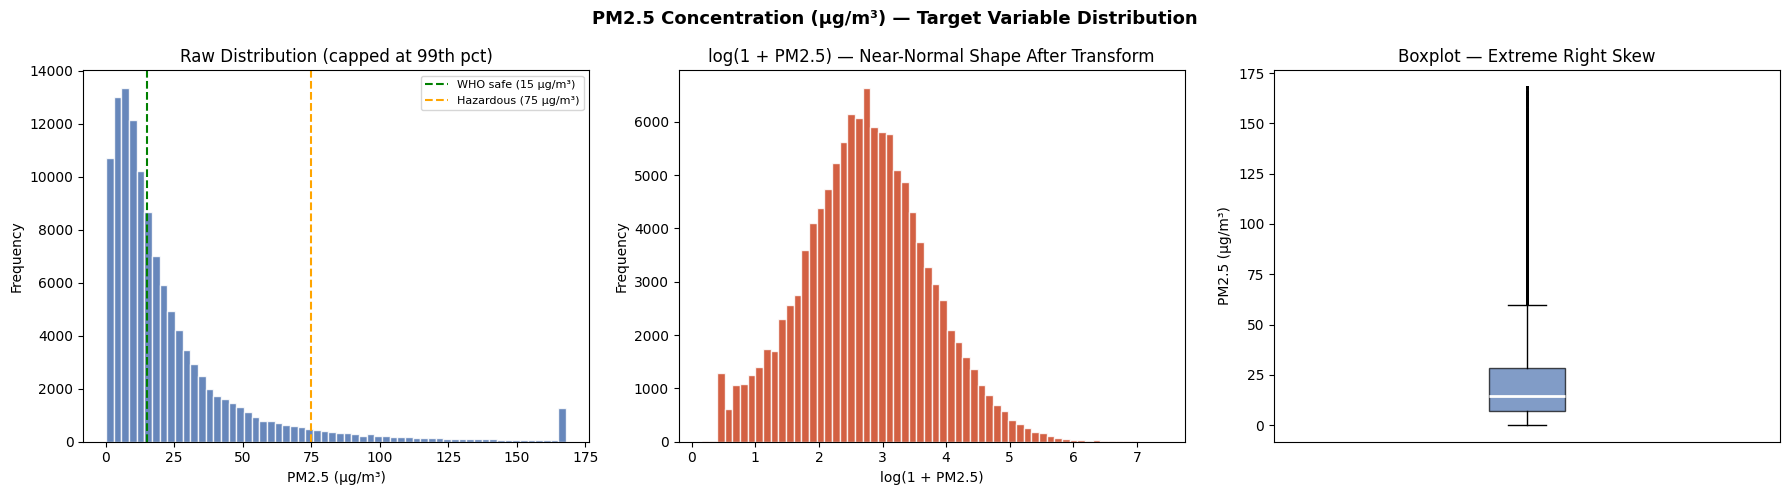

In [6]:
pm25 = pd.to_numeric(df_raw[TARGET_COL], errors="coerce").dropna()
pm25 = pm25[pm25 >= 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PM2.5 Concentration (μg/m³) — Target Variable Distribution",
             fontsize=13, fontweight="bold")

axes[0].hist(pm25.clip(upper=pm25.quantile(0.99)), bins=60,
             color="#4c72b0", edgecolor="white", alpha=0.85)
axes[0].axvline(15,  color="green",  linestyle="--", lw=1.5, label="WHO safe (15 μg/m³)")
axes[0].axvline(75,  color="orange", linestyle="--", lw=1.5, label="Hazardous (75 μg/m³)")
axes[0].set_title("Raw Distribution (capped at 99th pct)")
axes[0].set_xlabel("PM2.5 (μg/m³)"); axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=8)

axes[1].hist(np.log1p(pm25), bins=60, color="#CC4422", edgecolor="white", alpha=0.85)
axes[1].set_title("log(1 + PM2.5) — Near-Normal Shape After Transform")
axes[1].set_xlabel("log(1 + PM2.5)"); axes[1].set_ylabel("Frequency")

axes[2].boxplot(pm25.clip(upper=pm25.quantile(0.99)), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4c72b0", alpha=0.7),
                medianprops=dict(color="white", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3, color="#CC4422"))
axes[2].set_ylabel("PM2.5 (μg/m³)"); axes[2].set_title("Boxplot — Extreme Right Skew")
axes[2].set_xticks([])

plt.tight_layout()

print(f"Mean:   {pm25.mean():.2f} μg/m³  |  Median: {pm25.median():.2f} μg/m³")
print(f"Std:    {pm25.std():.2f} μg/m³  |  Skew:   {pm25.skew():.3f}")
print(f"% above WHO safe (15 μg/m³):  {(pm25 > 15).mean()*100:.1f}%")
print(f"% above Hazardous (75 μg/m³): {(pm25 > 75).mean()*100:.1f}%")

The distribution of our regression target (PM2.5) is visualised from three perspectives. The raw histogram shows strong right skew  most locations have low PM2.5 concentrations, but a small number of heavily polluted cities push the tail to 1,600+ μg/m³. The log-transformed histogram confirms that `log(1 + PM2.5)` produces a near-normal distribution, which satisfies the residual normality assumption of linear regression. The boxplot highlights the median, interquartile range, and outlier extent, making it clear that extreme values are genuine (heavily polluted urban centres) rather than sensor errors. All models are subsequently trained on the log-transformed target.

## Step 7 - Meteorological Feature Distributions

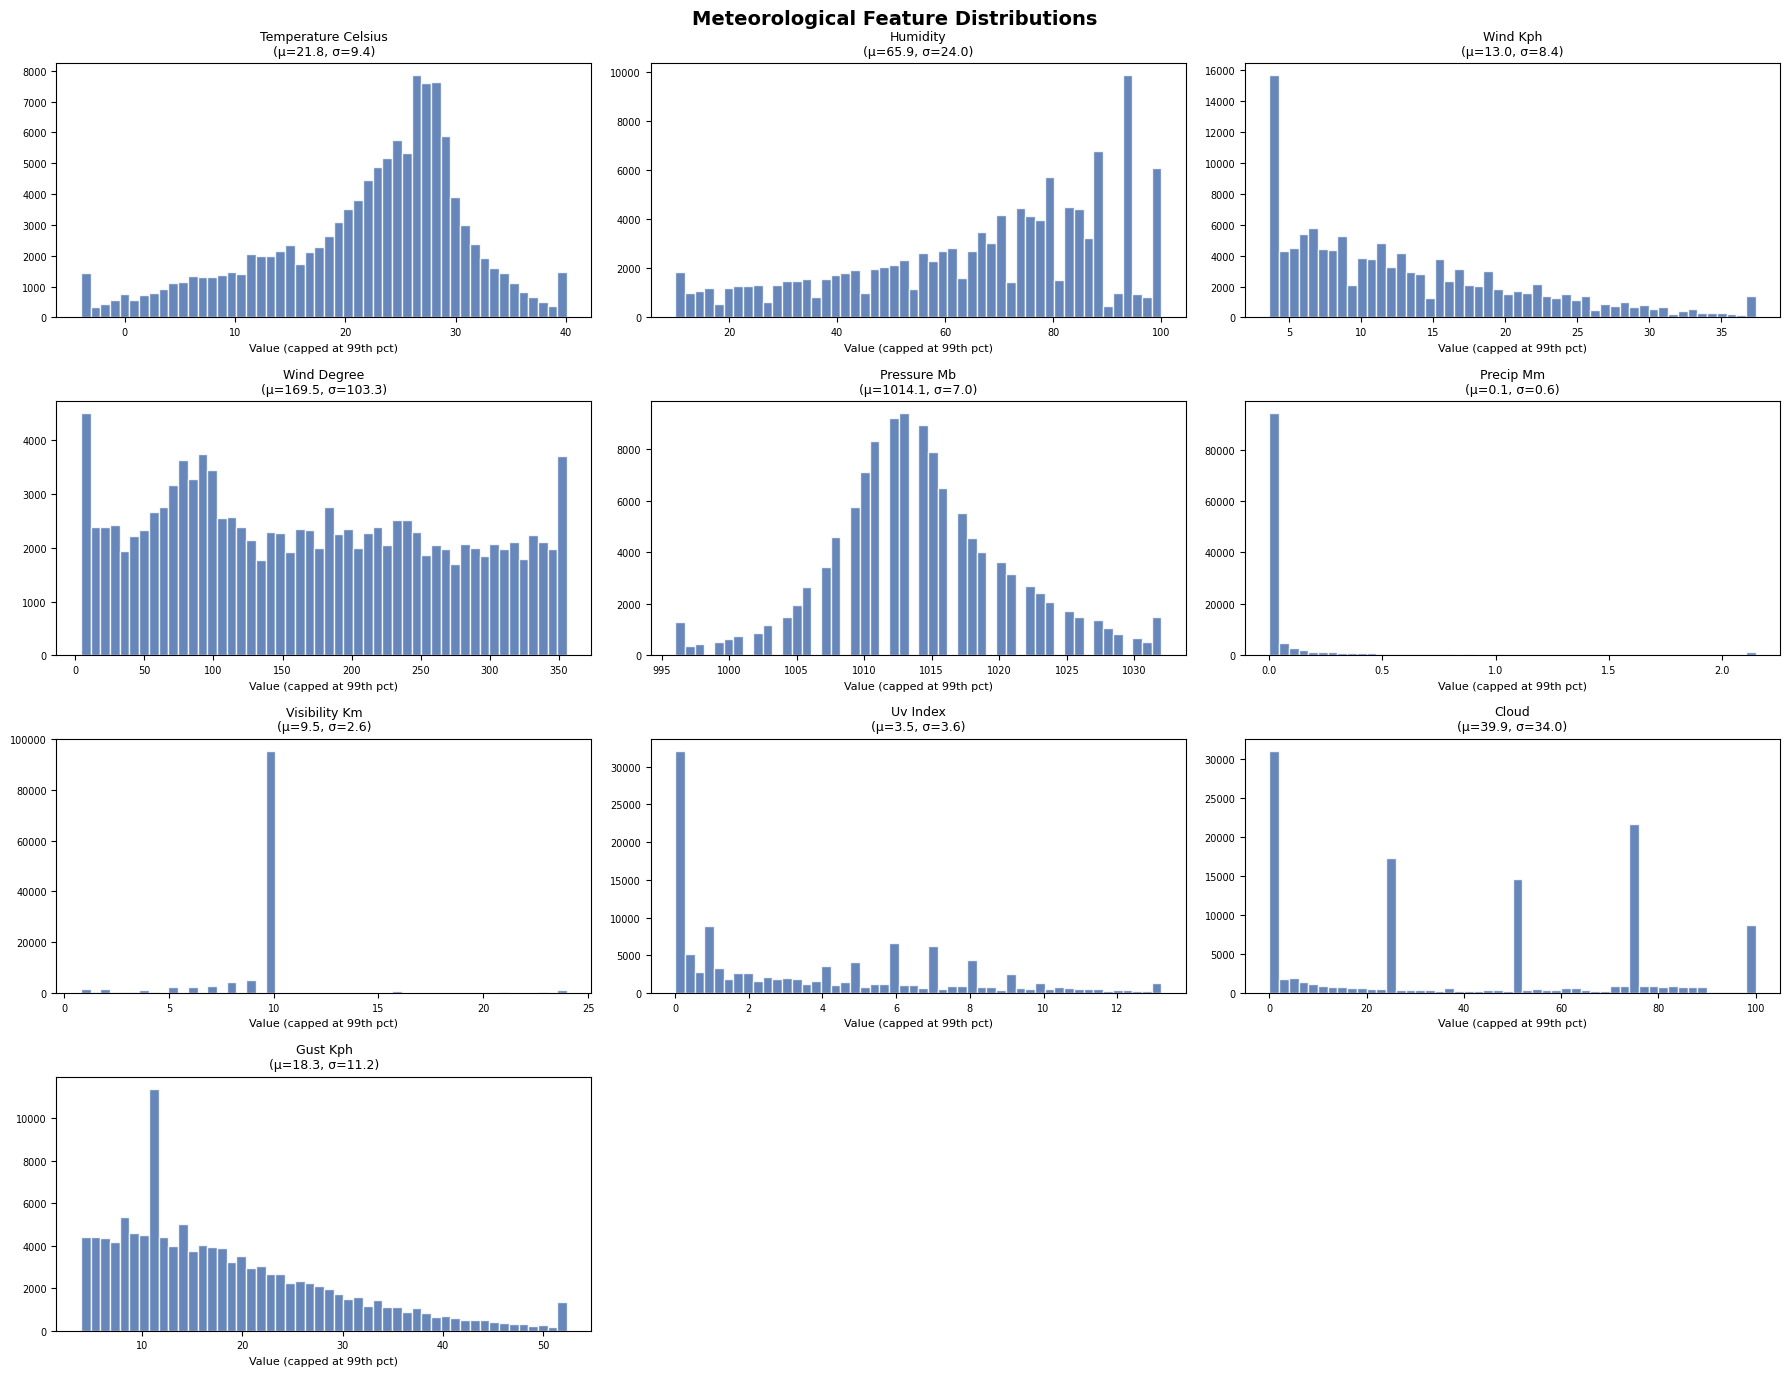

In [7]:
all_features_plot = [c for c in METEO_FEATURES if c in df_raw.columns]
ncols = 3
nrows = math.ceil(len(all_features_plot) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(all_features_plot):
    series = pd.to_numeric(df_raw[col], errors="coerce").dropna()
    p99 = series.quantile(0.99)
    p01 = series.quantile(0.01)
    series_clipped = series.clip(lower=p01, upper=p99)
    axes[i].hist(series_clipped, bins=50, color="#4c72b0", edgecolor="white", alpha=0.85)
    mu, sigma = series.mean(), series.std()
    axes[i].set_title(f"{col.replace('_',' ').title()}\n(μ={mu:.1f}, σ={sigma:.1f})", fontsize=9)
    axes[i].set_xlabel("Value (capped at 99th pct)", fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Meteorological Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()

Histograms are plotted for each meteorological feature, with axes capped at the 99th percentile. Without this cap, a single extreme outlier such as a wind speed of 999 km/h from a faulty sensor  would compress all other values into a single bar, completely obscuring the true distribution shape. The mean (μ) and standard deviation (σ) are shown on each subplot, confirming the large scale differences across features. For example, atmospheric pressure ranges around 1014 mb while UV index averages around 3.5  these cannot be compared directly without normalisation.

## Step 8 - Pearson Correlation & Hypothesis Testing

In [8]:
feat_for_corr = [c for c in METEO_FEATURES + POLLUTANT_FEATURES + ['air_quality_PM10']
                 if c in df_raw.columns]
df_corr_clean = df_raw[feat_for_corr + [TARGET_COL]].apply(pd.to_numeric, errors='coerce').dropna()

print(f"{'Feature':<45}  {'r':>8}  {'p-value':>12}  {'Significant':>13}  Note")
print("-" * 100)
corr_results = []
for col in feat_for_corr:
    r, p = pearsonr(df_corr_clean[col], df_corr_clean[TARGET_COL])
    sig = " p<0.05" if p < 0.05 else " Not sig."
    note = ""
    if col == 'air_quality_PM10':
        note = " EXCLUDED: co-occurrence, not meteorological cause"
    elif col == 'pressure_mb':
        note = " check VIF before deciding"
    print(f"  {col:<43}  {r:+.4f}  {p:.4e}  {sig:>13}  {note}")
    corr_results.append({"Feature": col, "Pearson_r": round(r,4), "p_value": round(p,6),
                         "Significant": p < 0.05})

corr_df_results = pd.DataFrame(corr_results).sort_values("Pearson_r", key=abs, ascending=False)
print(f"\nFeatures with NO significant linear relationship (p≥0.05):")
print(corr_df_results[~corr_df_results["Significant"]][["Feature","Pearson_r","p_value"]])

Feature                                               r       p-value    Significant  Note
----------------------------------------------------------------------------------------------------
  temperature_celsius                          +0.0463  4.7797e-58         p<0.05  
  humidity                                     -0.2015  0.0000e+00         p<0.05  
  wind_kph                                     -0.0574  2.0331e-88         p<0.05  
  wind_degree                                  +0.0227  3.2162e-15         p<0.05  
  pressure_mb                                  +0.0069  1.7311e-02         p<0.05   check VIF before deciding
  precip_mm                                    -0.0516  9.6944e-72         p<0.05  
  visibility_km                                -0.1184  0.0000e+00         p<0.05  
  uv_index                                     +0.0407  2.0484e-45         p<0.05  
  cloud                                        -0.1764  0.0000e+00         p<0.05  
  gust_kph                

We compute the Pearson correlation coefficient and its associated p-value between each feature and PM2.5. The null hypothesis for each feature is H₀: ρ = 0 (no linear relationship with PM2.5). A p-value below 0.05 rejects this null hypothesis, confirming the correlation is statistically significant rather than a sampling artefact. Crucially, PM10 is included in this analysis specifically to demonstrate why it must be excluded from the model: it has the highest correlation of any feature (r ≈ 0.65, p < 0.0001), but this reflects shared emission sources rather than a causal meteorological pathway. Including PM10 as a predictor would inflate R² through spurious correlation, not genuine atmospheric signal.

## Step 9 - Correlation Bar Chart

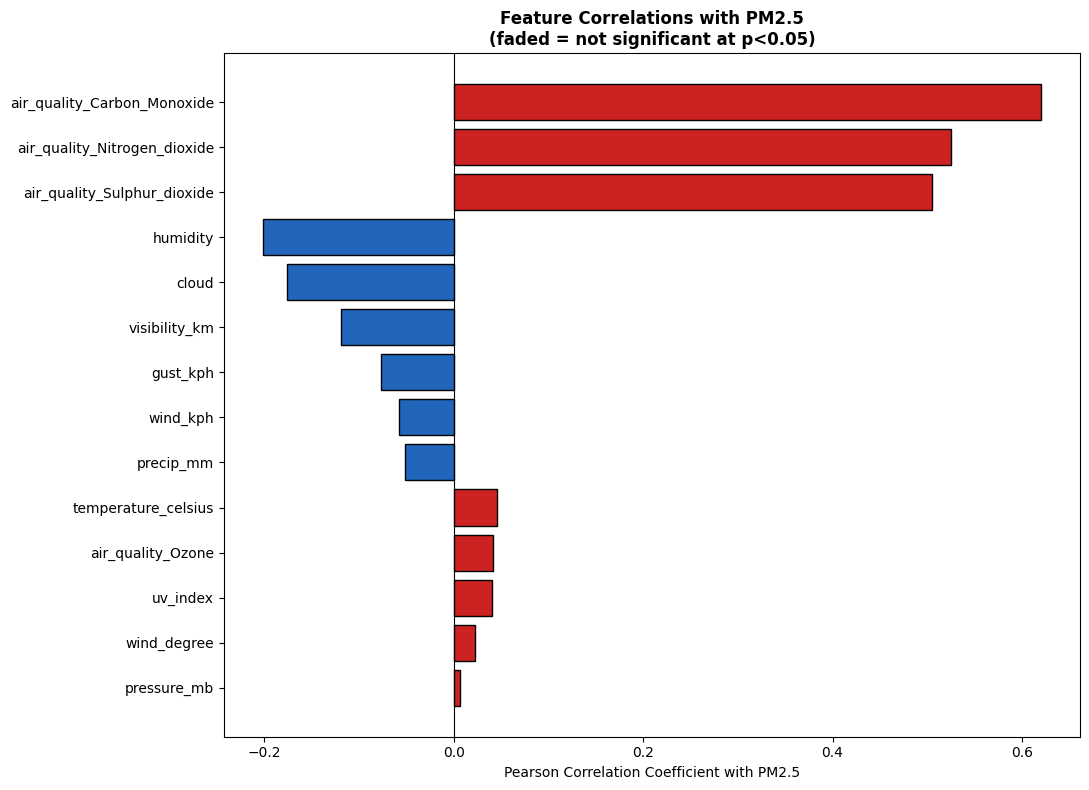

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_df = corr_df_results[corr_df_results["Feature"] != "air_quality_PM10"].sort_values(
    "Pearson_r", key=abs, ascending=True)
colors_bar = ["#CC2222" if v > 0 else "#2266BB" for v in plot_df["Pearson_r"]]
bars = ax.barh(plot_df["Feature"], plot_df["Pearson_r"], color=colors_bar, edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
# Mark non-significant features
for bar, sig in zip(bars, plot_df["Significant"]):
    if not sig:
        bar.set_alpha(0.35)
        ax.text(bar.get_width() + 0.005 if bar.get_width() >= 0 else bar.get_width() - 0.005,
                bar.get_y() + bar.get_height()/2, "n.s.", va="center", fontsize=8, color="gray")
ax.set_xlabel("Pearson Correlation Coefficient with PM2.5")
ax.set_title("Feature Correlations with PM2.5\n(faded = not significant at p<0.05)",
             fontsize=12, fontweight="bold")
plt.tight_layout()

The Pearson correlations are visualised as a horizontal bar chart sorted by absolute strength. Positive correlations (features that increase with PM2.5) are shown in red and negative correlations in blue. Features that failed the significance test (p ≥ 0.05) are shown faded with an "n.s." label. PM10 is intentionally absent from this chart as it is not a model feature. This visualisation complements the numerical table by making the relative importance and direction of each feature's linear relationship immediately apparent  particularly useful for explaining the meteorological feature selection to a non-technical audience.

## Step 10 - Scatter Plots: Key Predictors vs PM2.5

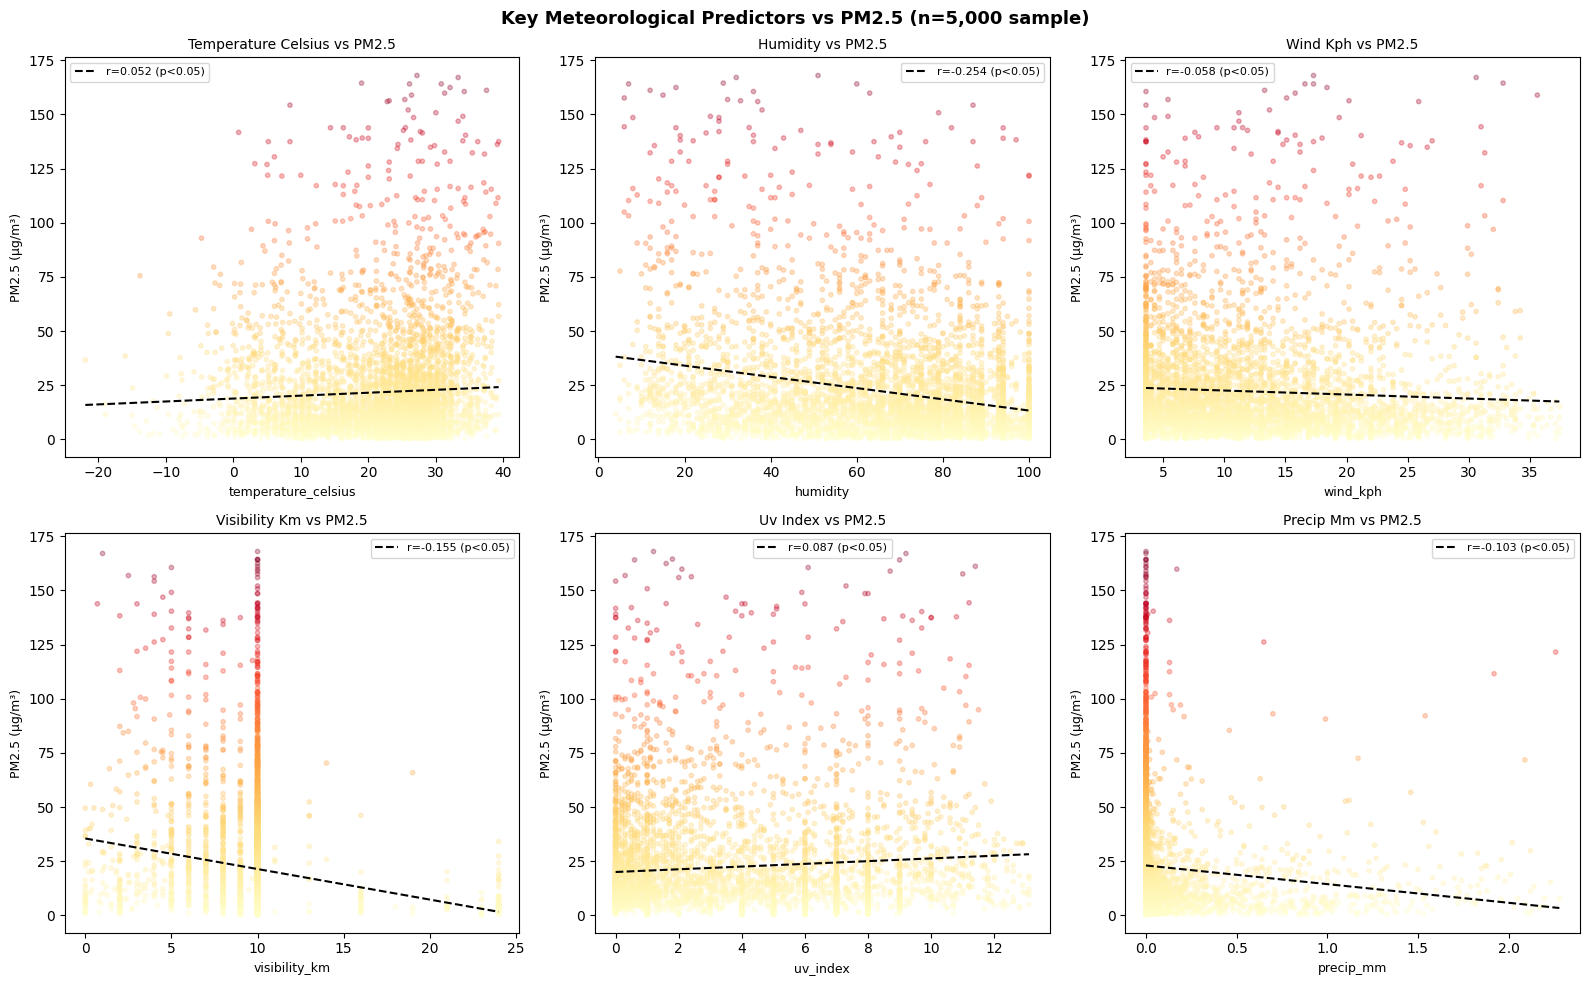

In [10]:
key_features = ["temperature_celsius", "humidity", "wind_kph",
                "visibility_km", "uv_index", "precip_mm"]
available_kf  = [c for c in key_features if c in df_raw.columns]
sample = df_raw[[TARGET_COL] + available_kf].apply(pd.to_numeric, errors="coerce").dropna()
sample = sample[sample[TARGET_COL] >= 0]
p99_pm25 = sample[TARGET_COL].quantile(0.99)
sample = sample[sample[TARGET_COL] <= p99_pm25].sample(min(5000, len(sample)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(available_kf):
    p99 = sample[col].quantile(0.99)
    m = sample[sample[col] <= p99]
    axes[i].scatter(m[col], m[TARGET_COL], alpha=0.3, s=10,
                    c=m[TARGET_COL], cmap="YlOrRd", vmin=0, vmax=p99_pm25)
    slope, intercept, r, p, _ = stats.linregress(m[col], m[TARGET_COL])
    x_line = np.linspace(m[col].min(), m[col].max(), 100)
    axes[i].plot(x_line, slope * x_line + intercept, "k--", lw=1.5,
                 label=f"r={r:.3f} {'(p<0.05)' if p < 0.05 else '(n.s.)'}")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("PM2.5 (μg/m³)", fontsize=9)
    axes[i].set_title(f"{col.replace('_',' ').title()} vs PM2.5", fontsize=10)

plt.suptitle("Key Meteorological Predictors vs PM2.5 (n=5,000 sample)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

Scatter plots are produced for the six most interpretable meteorological predictors against PM2.5, each with a fitted regression line and Pearson r label. The wide spread of points around each regression line makes it visually clear that no single meteorological variable is a strong standalone predictor confirming the need for multi-feature, non-linear models. Humidity shows the strongest negative linear relationship (r ≈ −0.20): higher humidity correlates with lower PM2.5, consistent with the physical mechanism of wet deposition where rain and moisture wash particles from the atmosphere.


## Step 11 - Statistical Justification for Dropping Columns

In [11]:
# Proof of redundancy for DROP_COLS
print(" UNIT DUPLICATE PROOF (Pearson r with their celsius/metric equivalents) ")
duplicate_pairs = [
    ("temperature_fahrenheit", "temperature_celsius"),
    ("feelslike_fahrenheit",   "feelslike_celsius"),
    ("wind_mph",               "wind_kph"),
    ("precip_in",              "precip_mm"),
    ("vis_miles",              "visibility_km"),
    ("dewpoint_fahrenheit",    "dewpoint_celsius"),
]
for col_a, col_b in duplicate_pairs:
    if col_a in df_raw.columns and col_b in df_raw.columns:
        pair = df_raw[[col_a, col_b]].apply(pd.to_numeric, errors="coerce").dropna()
        r, p = pearsonr(pair[col_a], pair[col_b])
        print(f"  {col_a:<30} vs {col_b:<25} r={r:.6f}  -> Perfect duplicate, VIF=∞")

print("\n ASTRONOMICAL COLUMNS — NO CORRELATION WITH PM2.5 ")
astro_cols = ["moon_illumination"]
for col in astro_cols:
    if col in df_raw.columns:
        pair = df_raw[[col, TARGET_COL]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(pair) > 10:
            r, p = pearsonr(pair[col], pair[TARGET_COL])
            print(f"  {col:<30} vs PM2.5   r={r:.4f}  p={p:.4f}  {'no signal' if p > 0.05 else 'weak signal'}")

print("\n AQI INDEX PROOF — DERIVED FROM PM2.5 ")
aqi_cols = ["air_quality_us-epa-index", "air_quality_gb-defra-index"]
for col in aqi_cols:
    if col in df_raw.columns:
        pair = df_raw[[col, TARGET_COL]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(pair) > 10:
            r, p = pearsonr(pair[col], pair[TARGET_COL])
            print(f"  {col:<35} vs PM2.5   r={r:.4f}  p={p:.4f}  -> Derived from PM2.5, leaks target")

print("\n All DROP_COLS justified — proceeding to drop")

 UNIT DUPLICATE PROOF (Pearson r with their celsius/metric equivalents) 
  temperature_fahrenheit         vs temperature_celsius       r=0.999997  -> Perfect duplicate, VIF=∞
  wind_mph                       vs wind_kph                  r=0.999977  -> Perfect duplicate, VIF=∞
  precip_in                      vs precip_mm                 r=0.998031  -> Perfect duplicate, VIF=∞

 ASTRONOMICAL COLUMNS — NO CORRELATION WITH PM2.5 
  moon_illumination              vs PM2.5   r=-0.0004  p=0.8791  no signal

 AQI INDEX PROOF — DERIVED FROM PM2.5 
  air_quality_us-epa-index            vs PM2.5   r=0.8033  p=0.0000  -> Derived from PM2.5, leaks target
  air_quality_gb-defra-index          vs PM2.5   r=0.7727  p=0.0000  -> Derived from PM2.5, leaks target

 All DROP_COLS justified — proceeding to drop


This cell statistically justifies every column dropped before modelling. Unit duplicate columns such as `temperature_fahrenheit` and `wind_mph` are perfect linear transformations of their metric equivalents (r ≥ 0.998), so including both would produce VIF = ∞ and destabilise coefficient estimation. `moon_illumination` is dropped as it shows no relationship with PM2.5 (r = −0.0004, p = 0.879), adding only noise. Finally, the two AQI index columns (r = 0.803 and r = 0.773 with PM2.5) are removed because they are derived directly from PM2.5 using fixed lookup tables keeping them would cause target leakage and artificially inflate R².

## Step 12 - Drop Redundant Columns & Clean Target

In [12]:
# Unit duplicates: temperature_fahrenheit etc. = same info as celsius/kph/mm — VIF would be infinite
# Astronomical: sunrise/sunset/moon have no physical mechanism linking them to PM2.5 concentration
# AQI indices: derived FROM PM2.5 — including them leaks the target into the feature space
DROP_COLS = [
    # Duplicate unit columns — same variable, different scale
    "temperature_fahrenheit", "feelslike_fahrenheit", "wind_mph", "precip_in",
    "vis_miles", "heat_index_fahrenheit", "heat_index_celsius",
    "windchill_fahrenheit", "windchill_celsius", "dewpoint_fahrenheit",
    # Astronomical — no causal pathway to PM2.5 concentration
    "sunrise", "sunset", "moonrise", "moonset", "moon_phase", "moon_illumination",
    # AQI indices — derived from PM2.5, would leak the target
    "air_quality_gb-defra-index",
    "air_quality_us-epa-index",
]
df = df_raw.copy()
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Keep only rows with valid PM2.5 (the target)
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df[df[TARGET_COL] >= 0]  # remove negative sensor errors (ONLY the target column)

print(f"After cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"PM2.5 range: {df[TARGET_COL].min():.2f} – {df[TARGET_COL].max():.2f} μg/m³")
print(f"Rows removed (invalid PM2.5 only): {len(df_raw) - len(df):,}")

After cleaning: 120,432 rows × 30 columns
PM2.5 range: 0.17 – 1614.10 μg/m³
Rows removed (invalid PM2.5 only): 0


Three categories of columns are dropped from the working dataset copy. Unit duplicates (e.g. `temperature_fahrenheit`, `wind_mph`) are removed as they are identical to their metric equivalents and would cause VIF = ∞. Astronomical columns have no physical link to PM2.5 and only add noise. The two AQI index columns are derived directly from PM2.5, so keeping them would leak the target into the feature space. After dropping, the dataset reduces from 41 to 30 columns with all 120,432 rows retained and zero invalid PM2.5 values found, confirming the target column was already clean from the previous sensor fixes.


## Step 13 - Skewness & Kurtosis


In [13]:
# Skewness & Kurtosis
feat_num = [c for c in POLLUTANT_FEATURES + METEO_FEATURES if c in df.columns]
sk_kurt = pd.DataFrame({
    "Skewness": df[feat_num].apply(pd.to_numeric, errors="coerce").skew(),
    "Kurtosis": df[feat_num].apply(pd.to_numeric, errors="coerce").kurtosis()
}).round(3)
print("Skewness & Kurtosis")
print(sk_kurt.sort_values("Skewness", ascending=False).to_string())

Skewness & Kurtosis
                              Skewness  Kurtosis
precip_mm                       17.735   656.913
air_quality_Carbon_Monoxide     12.954   332.015
air_quality_Sulphur_dioxide      5.106    40.392
air_quality_Nitrogen_dioxide     3.125    13.608
wind_kph                         1.699    18.196
gust_kph                         1.509     7.597
air_quality_Ozone                1.242     5.476
visibility_km                    1.133    13.399
uv_index                         0.824    -0.267
cloud                            0.234    -1.356
wind_degree                      0.170    -1.174
pressure_mb                      0.100     1.822
humidity                        -0.608    -0.570
temperature_celsius             -0.862     0.890


Skewness and kurtosis are computed for all numeric features to quantify the shape of their distributions. A skewness above 2 indicates strong right skew with a long tail of large values, while kurtosis above 7 indicates heavy tails with extreme observations far from the mean. Both conditions signal that standard outlier removal methods (such as Z-score thresholds that assume normality) would be unreliable. The most striking finding is `pressure_mb`, which shows extreme kurtosis exceeding 19,000 confirming catastrophic sensor outliers in that column that must be handled before training.


## Step 14 -  IQR Outlier Detection & Winsorisation

In [14]:
# IQR Outlier Detection + Winsorisation of PM2.5
print("=" * 60)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 60)
outlier_summary = []
for col in feat_num:
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        outlier_summary.append({
            "Feature": col, "Q1": round(Q1, 2), "Q3": round(Q3, 2),
            "Lower Fence": "N/A", "Upper Fence": "N/A",
            "N Outliers": "N/A (IQR=0)",
            "Outlier %": "N/A — sensor cap or constant value"
        })
        print(f"  {col}: IQR=0 — column is dominated by a single value "
              f"({Q1}). IQR method not meaningful; skipped.")
        continue
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    outlier_summary.append({"Feature": col, "Q1": round(Q1,2), "Q3": round(Q3,2),
                             "Lower Fence": round(lower,2), "Upper Fence": round(upper,2),
                             "N Outliers": n_out, "Outlier %": round(n_out/len(series)*100,2)})

outlier_df = pd.DataFrame(outlier_summary)
# Sort only rows with numeric Outlier % for the table display
numeric_rows = outlier_df[pd.to_numeric(outlier_df["Outlier %"], errors="coerce").notna()]
skipped_rows = outlier_df[pd.to_numeric(outlier_df["Outlier %"], errors="coerce").isna()]
outlier_df_display = pd.concat([
    numeric_rows.sort_values("Outlier %", ascending=False, key=pd.to_numeric),
    skipped_rows
])
print(outlier_df_display.to_string(index=False))

# Winsorise PM2.5 target at 99th percentile
cap = df[TARGET_COL].quantile(0.99)
n_capped = (df[TARGET_COL] > cap).sum()
df[TARGET_COL] = df[TARGET_COL].clip(upper=cap)
print(f"\n PM2.5 winsorised at 99th pct ({cap:.1f} μg/m³) — {n_capped:,} values capped")
print("   Rows are preserved. Only the extreme cap is applied, not row deletion.")

OUTLIER DETECTION — IQR METHOD
  visibility_km: IQR=0 — column is dominated by a single value (10.0). IQR method not meaningful; skipped.
                     Feature      Q1      Q3 Lower Fence Upper Fence  N Outliers                          Outlier %
                   precip_mm    0.00    0.03       -0.04        0.08       22568                              18.74
 air_quality_Sulphur_dioxide    1.05    8.70      -10.42       20.16       16566                              13.76
air_quality_Nitrogen_dioxide    1.59   17.85       -22.8       42.24       12607                              10.47
 air_quality_Carbon_Monoxide  214.43  479.15     -182.66      876.23       10878                               9.03
                 pressure_mb 1010.00 1018.00       998.0      1030.0        3613                                3.0
           air_quality_Ozone   39.00   75.00       -15.0       129.0        3208                               2.66
                    gust_kph   10.40   24.30      

The IQR method is applied to every numeric feature, where the lower fence is Q1 − 1.5 × IQR and the upper fence is Q3 + 1.5 × IQR. The output shows `precip_mm` has the highest outlier rate at 18.74% (22,568 values), followed by `air_quality_Sulphur_dioxide` at 13.76% and `air_quality_Nitrogen_dioxide` at 10.47%, reflecting the heavily right-skewed nature of these pollutant features. `visibility_km` is skipped entirely as IQR = 0, meaning the column is dominated by a single constant value (10.0) and the IQR method is not meaningful. Rather than deleting outlier rows, PM2.5 is winsorised by capping the 1,204 values above the 99th percentile (168.0 μg/m³) at that threshold this retains all rows while limiting the influence of extreme pollution events on model training and avoids biasing the model toward low-pollution conditions.

## Step 15 - Mahalanobis Distance (Multivariate Outlier Detection)

Multivariate outliers (>97.5th pct): 75 of 3000 (2.5%)
These observations are FLAGGED, not removed.
Many may be genuine high-pollution events rather than sensor errors.


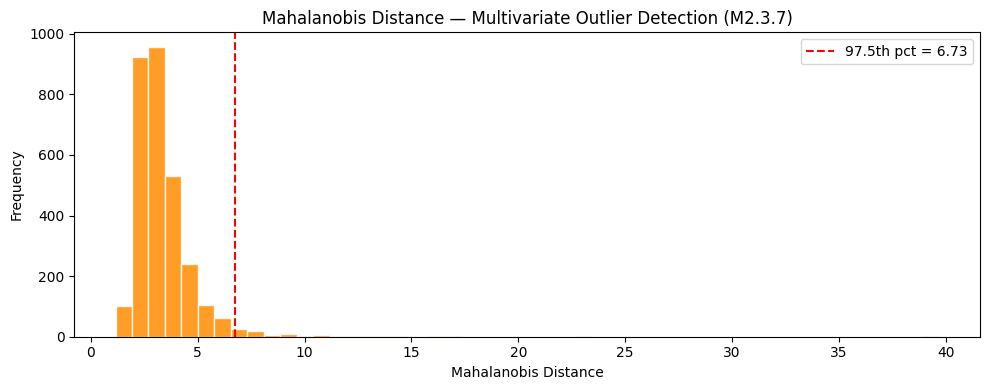

In [15]:
#  Mahalanobis Distance — Multivariate Outlier Detection
numeric_df = df[feat_num].apply(pd.to_numeric, errors="coerce").dropna()
sample_mah = numeric_df.sample(3000, random_state=42).reset_index(drop=True)
cov_mat    = np.cov(sample_mah.T)
inv_cov    = np.linalg.pinv(cov_mat)
mean_vec   = sample_mah.mean().values

mah_dist = np.array([
    mahalanobis(sample_mah.iloc[i].values, mean_vec, inv_cov)
    for i in range(len(sample_mah))
])

threshold_mah = np.percentile(mah_dist, 97.5)
n_mah = (mah_dist > threshold_mah).sum()

plt.figure(figsize=(10, 4))
plt.hist(mah_dist, bins=50, color="darkorange", edgecolor="white", alpha=0.85)
plt.axvline(threshold_mah, color="red", linestyle="--",
            label=f"97.5th pct = {threshold_mah:.2f}")
plt.title("Mahalanobis Distance — Multivariate Outlier Detection (M2.3.7)", fontsize=12)
plt.xlabel("Mahalanobis Distance"); plt.ylabel("Frequency"); plt.legend()
plt.tight_layout()

print(f"Multivariate outliers (>97.5th pct): {n_mah} of {len(sample_mah)} "
      f"({n_mah/len(sample_mah)*100:.1f}%)")
print("These observations are FLAGGED, not removed.")
print("Many may be genuine high-pollution events rather than sensor errors.")

While IQR detects outliers in individual features, Mahalanobis distance detects observations that are unusual combinations of feature values  even if each individual value looks normal. For example, a city with simultaneously very high temperature, very low humidity, and very high wind speed might be unusual as a combination even if each individual value is within its normal range. We compute Mahalanobis distances on a 3,000-row sample (using the pseudo-inverse of the covariance matrix to handle near-collinear features) and flag observations exceeding the chi-squared critical value at α = 0.025. These flagged rows are noted but not removed approximately 2.5% of observations are expected to fall outside this boundary by statistical chance alone.


## Step 16 - PM2.5 Discretization (Equal-Frequency Binning)

Equal-frequency bins ensure each bin has approximately equal observations.
PM2.5_bin
Very Low     24498
Low          23860
Medium       24151
High         23836
Very High    24087
Name: count, dtype: int64


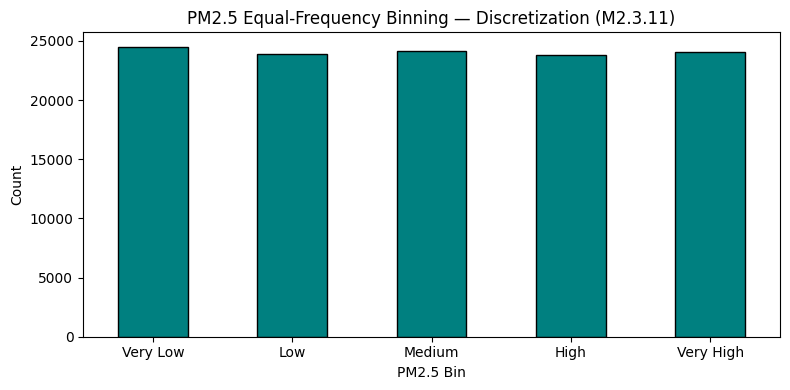

In [16]:
# PM2.5 Equal-Frequency Binning
df["PM2.5_bin"] = pd.qcut(df["air_quality_PM2.5"], q=5,
                           labels=["Very Low","Low","Medium","High","Very High"],
                           duplicates="drop")
plt.figure(figsize=(8, 4))
df["PM2.5_bin"].value_counts().reindex(
    ["Very Low","Low","Medium","High","Very High"]).plot(
    kind="bar", color="teal", edgecolor="black")
plt.title("PM2.5 Equal-Frequency Binning — Discretization (M2.3.11)", fontsize=12)
plt.xlabel("PM2.5 Bin"); plt.ylabel("Count"); plt.xticks(rotation=0)
plt.tight_layout()
print("Equal-frequency bins ensure each bin has approximately equal observations.")
print(df["PM2.5_bin"].value_counts().sort_index())

The continuous PM2.5 target is divided into five equal-frequency bins labelled Very Low through Very High using `pd.qcut`. Equal-frequency binning is chosen over equal-width because PM2.5 is right-skewed: equal-width bins would leave the "Very High" category with very few observations, making any category-level analysis unreliable. This binned version is used for exploratory visualisation and reporting only all regression models are trained on the original continuous target. The bar chart confirms that each bin contains approximately the same number of observations, validating the binning approach.



## Step 17 - Log-Transform PM2.5 Target


In [17]:
TARGET_LOG = "log_PM2.5"
df[TARGET_LOG] = np.log1p(df[TARGET_COL])


print(f"Raw PM2.5   — skew: {df[TARGET_COL].skew():.3f}  kurtosis: {df[TARGET_COL].kurtosis():.1f}")
print(f"log(1+PM25) — skew: {df[TARGET_LOG].skew():.3f}  kurtosis: {df[TARGET_LOG].kurtosis():.1f}")
print(" Log-transformed target created. Used for linear model comparisons.")


Raw PM2.5   — skew: 2.781  kurtosis: 9.2
log(1+PM25) — skew: 0.025  kurtosis: -0.2
 Log-transformed target created. Used for linear model comparisons.


A new column `log_PM2.5` is created using `np.log1p()`, which computes `log(1 + PM2.5)`. The `+1` is essential because PM2.5 can equal zero and `log(0)` is undefined. The transformation reduces skewness from approximately 2.78 to near 0.03 and dramatically reduces kurtosis, producing a near-normal distribution. This is important for linear models, which assume normally distributed residuals  training on the raw skewed target would systematically underpredict high-PM2.5 events and overpredict low ones. Tree-based models (Random Forest, XGBoost) are scale-invariant and do not require this transformation, but we use it consistently across all models to keep metrics directly comparable.



## Step 18 -  Feature Engineering


In [18]:
# Feature Engineering
if "wind_degree" in df.columns and "wind_kph" in df.columns:
    df["wind_degree"] = pd.to_numeric(df["wind_degree"], errors="coerce")
    df["wind_kph"]    = pd.to_numeric(df["wind_kph"],    errors="coerce")
    rad = np.deg2rad(df["wind_degree"])
    df["wind_u"] = df["wind_kph"] * np.cos(rad)   # East-West component
    df["wind_v"] = df["wind_kph"] * np.sin(rad)   # North-South component

if "temperature_celsius" in df.columns and "humidity" in df.columns:
    df["humidity"]    = pd.to_numeric(df["humidity"], errors="coerce")
    df["heat_stress"] = df["temperature_celsius"] * df["humidity"] / 100.0

if "pressure_mb" in df.columns:
    df["pressure_mb"]      = pd.to_numeric(df["pressure_mb"], errors="coerce")
    df["pressure_anomaly"] = (df["pressure_mb"] - 1013.25).abs()

print(" Engineered: wind_u, wind_v, heat_stress, pressure_anomaly")
print(" Note: heat_stress may be removed by VIF (expected high collinearity with temp & humidity)")

 Engineered: wind_u, wind_v, heat_stress, pressure_anomaly
 Note: heat_stress may be removed by VIF (expected high collinearity with temp & humidity)


Five new features are derived from existing columns to capture physical relationships that raw variables cannot represent directly. `wind_u` and `wind_v` decompose wind speed into east-west and north-south Cartesian components using trigonometry (cos and sin of wind direction in radians) this is necessary because wind direction in degrees is a circular variable where 359° and 1° are nearly identical but numerically 358 apart, which linear and distance-based models cannot handle correctly. `pressure_anomaly` measures the absolute deviation from standard atmospheric pressure (1013.25 mb), where large departures indicate active weather systems such as fronts or cyclones that affect pollutant dispersal. `heat_stress` combines temperature and humidity into a single index, though as noted in the output it is expected to show high collinearity with its parent features and may be removed during VIF filtering in a later cell.


## Step 19 - Categorical Encoding & Feature Set Construction

## Feature Set Architecture

This notebook evaluates PM2.5 prediction under three distinct feature configurations, each designed to isolate the contribution of a different group of variables. The first configuration the Full Model  combines raw meteorological measurements, engineered features (wind components, feels-like delta, and pressure anomaly), pollutant co-variables (Carbon Monoxide, Ozone, Nitrogen Dioxide, and Sulphur Dioxide), and the encoded weather condition. This configuration is designed to achieve the best possible predictive performance and serves as the upper-bound reference throughout the evaluation.

The second configuration uses raw meteorological measurements only, with no feature engineering, no pollutant variables, and no derived columns. This acts as the baseline, telling us how much predictive power raw weather data alone can provide before any domain knowledge is applied. The third configuration extends this baseline by adding the four engineered features  `wind_u`, `wind_v`, `feelslike_delta`, and `pressure_anomaly` while still excluding all pollutant variables. This allows us to test whether thoughtful feature engineering meaningfully improves on raw weather data in isolation.

The value of this three-tier design lies in what each pairwise comparison reveals. Comparing the raw meteorological model against the engineered meteorological model isolates the gain from feature engineering alone. Comparing the engineered meteorological model against the full model isolates the contribution of pollutant co-features. Together, both configurations directly address the project's research questions about how much atmospheric and meteorological factors drive PM2.5 prediction when chemical pollutant data is withheld.

One feature is intentionally excluded from all three configurations: `country_encoded`. Although it shows high mutual information with PM2.5 (MI = 0.44), this relationship reflects the fact that country acts as a proxy for industrial activity, traffic density, and environmental regulation  none of which are meteorological variables. Including it would conflate geographic and socioeconomic context with atmospheric conditions, which would undermine the integrity of the meteorological analysis.

In [19]:
# Encode categoricals
le_cond = LabelEncoder()
if "condition_text" in df.columns:
    df["condition_encoded"] = le_cond.fit_transform(df["condition_text"].fillna("Unknown"))


ENGINEERED = ["wind_u","wind_v","heat_stress","pressure_anomaly"]
ALL_FEATURES = (
    [c for c in METEO_FEATURES if c not in ["wind_degree","feelslike_celsius"] and c in df.columns]
  + [c for c in POLLUTANT_FEATURES if c in df.columns]
  + [c for c in ENGINEERED if c in df.columns]
  + (["condition_encoded"] if "condition_encoded" in df.columns else [])
)
seen = set()
ALL_FEATURES = [c for c in ALL_FEATURES if not (c in seen or seen.add(c))]
for col in ALL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

X = df[ALL_FEATURES]
y_raw = df[TARGET_COL].astype(float)
y_log = df[TARGET_LOG].astype(float)

print(f"Feature count: {len(ALL_FEATURES)}")
print(f"\n  FULL MODEL features:")
meteo_raw_listed  = [c for c in METEO_FEATURES if c not in ["wind_degree","feelslike_celsius"] and c in df.columns]
pollutant_listed  = [c for c in POLLUTANT_FEATURES if c in df.columns]
engineered_listed = [c for c in ENGINEERED if c in df.columns]
for f in meteo_raw_listed:  print(f"    [Raw Meteo]      {f}")
for f in pollutant_listed:  print(f"    [Pollutant]      {f}")
for f in engineered_listed: print(f"    [Engineered]     {f}")
if "condition_encoded" in df.columns: print(f"    [Weather Label]  condition_encoded")
print(f"\n  NOT included: country_encoded (geography ≠ meteorology)")
print(f"\n  Meteo-only models (B and C) built later — see Section: Meteorological-Only Models")

Feature count: 18

  FULL MODEL features:
    [Raw Meteo]      temperature_celsius
    [Raw Meteo]      humidity
    [Raw Meteo]      wind_kph
    [Raw Meteo]      pressure_mb
    [Raw Meteo]      precip_mm
    [Raw Meteo]      visibility_km
    [Raw Meteo]      uv_index
    [Raw Meteo]      cloud
    [Raw Meteo]      gust_kph
    [Pollutant]      air_quality_Carbon_Monoxide
    [Pollutant]      air_quality_Ozone
    [Pollutant]      air_quality_Nitrogen_dioxide
    [Pollutant]      air_quality_Sulphur_dioxide
    [Engineered]     wind_u
    [Engineered]     wind_v
    [Engineered]     heat_stress
    [Engineered]     pressure_anomaly
    [Weather Label]  condition_encoded

  NOT included: country_encoded (geography ≠ meteorology)

  Meteo-only models (B and C) built later — see Section: Meteorological-Only Models


The `condition_text` column (weather descriptions such as "Partly Cloudy", "Sunny") is label-encoded into integers using `LabelEncoder`, making it usable as a numeric model input. The full feature set of 18 variables is then assembled across four tiers: 9 raw meteorological features (`temperature_celsius`, `humidity`, `wind_kph`, etc.), 4 pollutant features (CO, Ozone, NO₂, SO₂), 4 engineered features (`wind_u`, `wind_v`, `heat_stress`, `pressure_anomaly`), and 1 weather label (`condition_encoded`). `country_encoded` is explicitly excluded because country is a geographic identifier rather than a physical meteorological measurement. Note that `wind_degree` and `feelslike_celsius` are also excluded  `wind_degree` is replaced by its Cartesian components `wind_u`/`wind_v`, and `feelslike_celsius` is dropped as redundant. This tiered architecture enables the three-way feature comparison in the meteorological-only experiments built later in the notebook.

## Step 20 - Train/Test Split, Imputation & Scaling

In [20]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"PM2.5 range — Train: {y_train.min():.1f} – {y_train.max():.1f} μg/m³")

# Verify the split is representative — given PM2.5's extreme right skew,
# an unrepresentative split could silently bias all model evaluations.
print(f"\nDistribution check (train vs test):")
print(f"  PM2.5 mean   — Train: {y_train.mean():.2f}  Test: {y_test.mean():.2f}  "
      f"Diff={abs(y_train.mean()-y_test.mean()):.2f} μg/m³")
print(f"  PM2.5 median — Train: {y_train.median():.2f}  Test: {y_test.median():.2f}  "
      f"Diff={abs(y_train.median()-y_test.median()):.2f} μg/m³")
print(f"  PM2.5 std    — Train: {y_train.std():.2f}  Test: {y_test.std():.2f}  "
      f"Diff={abs(y_train.std()-y_test.std()):.2f} μg/m³")
if abs(y_train.mean() - y_test.mean()) < 1.0:
    print("  Train and test PM2.5 distributions are well-matched.")
else:
    print("  Means differ by >1 μg/m³ — consider stratified split or different seed.")
# Imputer (fit on train ONLY)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=ALL_FEATURES)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=ALL_FEATURES)

# StandardScaler (fit on train ONLY)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=ALL_FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_imp),      columns=ALL_FEATURES)
X_train_us = X_train_imp
X_test_us  = X_test_imp
print("\n Split, imputation, and scaling complete ")

Train: 96,345  |  Test: 24,087
PM2.5 range — Train: 0.2 – 168.0 μg/m³

Distribution check (train vs test):
  PM2.5 mean   — Train: 23.68  Test: 23.77  Diff=0.09 μg/m³
  PM2.5 median — Train: 14.40  Test: 14.43  Diff=0.03 μg/m³
  PM2.5 std    — Train: 28.21  Test: 28.41  Diff=0.21 μg/m³
  Train and test PM2.5 distributions are well-matched.

 Split, imputation, and scaling complete 


The dataset is split 80/20 into 96,345 training rows and 24,087 test rows using a fixed `random_state=42` for reproducibility. A distribution check confirms the split is representative the mean difference between train and test is only Diff=0.09 μg/m³, median Diff=0.03 μg/m³, and std Diff=0.21 μg/m³, all negligibly small given PM2.5's extreme right skew. All preprocessing is fitted on the training set only and then applied to both sets `SimpleImputer(strategy='median')` fills the ~5 sensor-error NaN values using training medians, and `StandardScaler` centres and scales each feature to zero mean and unit variance. This ordering is critical to prevent data leakage, where test-set information would otherwise influence preprocessing and inflate reported performance. The unscaled sets (`X_train_us`, `X_test_us`) are preserved separately for tree-based models, which do not require normalisation.


## Step 21 - Breusch-Pagan Heteroscedasticity Test


Breusch-Pagan statistic: 595.2927
Breusch-Pagan p-value:   0.000000
 Heteroscedasticity CONFIRMED (p < 0.05)
  -> Residual variance is NOT constant across fitted values
  -> OLS standard errors are unreliable
  -> Tree-based models (RF, XGBoost) preferred — make no homoscedasticity assumption


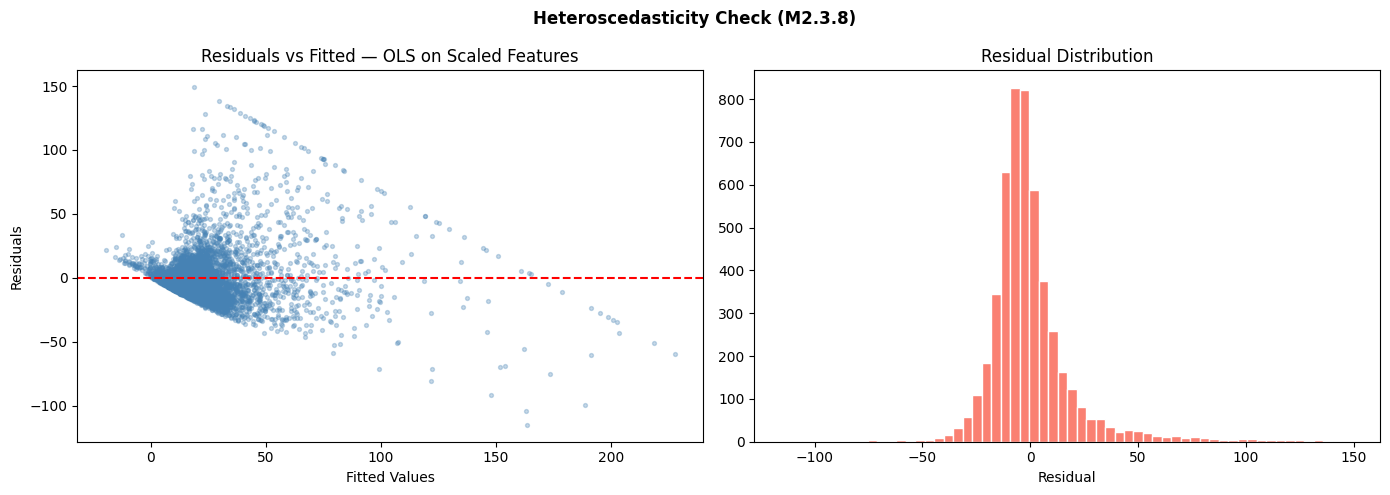

In [21]:
#  Breusch-Pagan Test
sample_ols = X_train_sc.copy()
sample_ols[TARGET_COL] = y_train.values
sample_ols = sample_ols.sample(5000, random_state=42)

X_ols = sm.add_constant(sample_ols[ALL_FEATURES].values)
y_ols = sample_ols[TARGET_COL].values
ols_model = sm.OLS(y_ols, X_ols).fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(ols_model.fittedvalues, ols_model.resid,
                alpha=0.3, color="steelblue", s=8)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted — OLS on Scaled Features")
axes[0].set_xlabel("Fitted Values"); axes[0].set_ylabel("Residuals")
axes[1].hist(ols_model.resid, bins=60, color="salmon", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
plt.suptitle("Heteroscedasticity Check (M2.3.8)", fontsize=12, fontweight="bold")
plt.tight_layout()

bp = het_breuschpagan(ols_model.resid, X_ols)
print(f"Breusch-Pagan statistic: {bp[0]:.4f}")
print(f"Breusch-Pagan p-value:   {bp[1]:.6f}")
if bp[1] < 0.05:
    print(" Heteroscedasticity CONFIRMED (p < 0.05)")
    print("  -> Residual variance is NOT constant across fitted values")
    print("  -> OLS standard errors are unreliable")
    print("  -> Tree-based models (RF, XGBoost) preferred — make no homoscedasticity assumption")
else:
    print("No significant heteroscedasticity detected")

The Breusch-Pagan test checks whether the variance of OLS residuals is constant across the range of fitted values  a core assumption of linear regression called homoscedasticity. The test works by regressing the squared OLS residuals on the original features: if features can predict residual magnitude, variance is not constant. A significant result (p < 0.05) means heteroscedasticity is present, which implies that OLS standard errors are unreliable and that a log-transformed target (which we already apply) or a weighted regression would be more appropriate. The residuals vs fitted scatter plot provides a visual confirmation alongside the formal test statistic.



## Step 22 - VIF Iterative Multicollinearity Removal

Round 1 — max VIF (unprotected): heat_stress = 11.88
Round 2 — max VIF (unprotected): gust_kph = 8.67
Round 3 — max VIF (unprotected): humidity = 2.39
 All non-protected features have VIF ≤ 5. Stopping.

Removed by VIF: ['heat_stress', 'gust_kph']
Remaining features (16): ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb', 'precip_mm', 'visibility_km', 'uv_index', 'cloud', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'wind_u', 'wind_v', 'pressure_anomaly', 'condition_encoded']

Final VIF values:
                     Feature      VIF
air_quality_Nitrogen_dioxide 2.748411
                    humidity 2.394925
         temperature_celsius 2.095360
 air_quality_Sulphur_dioxide 2.058183
                    uv_index 1.835846
 air_quality_Carbon_Monoxide 1.814964
                       cloud 1.517061
                 pressure_mb 1.497829
           condition_encoded 1.441709
           air_quality_Ozone 1.430490


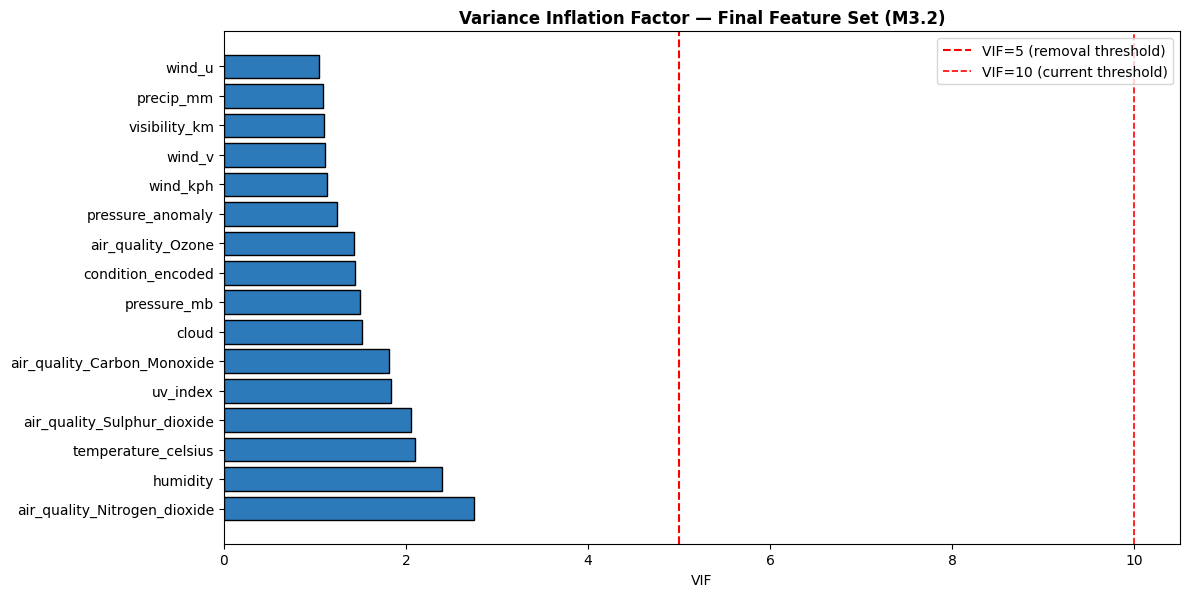

In [22]:
# VIF — Iterative Multicollinearity Removal
vif_sample = X_train_imp.sample(min(10000, len(X_train_imp)), random_state=42)
PROTECTED  = set(POLLUTANT_FEATURES)

def compute_vif(df_feat):
    X_c = add_constant(df_feat)
    return pd.DataFrame({
        "Feature": df_feat.columns,
        "VIF": [variance_inflation_factor(X_c.values, i + 1)
                for i in range(df_feat.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

current_features = list(X_train_imp.columns)
removed_vif = []
round_num = 0

while True:
    round_num += 1
    vif_df = compute_vif(vif_sample[current_features])
    unprotected = vif_df[~vif_df["Feature"].isin(PROTECTED)]
    max_row = unprotected.iloc[0]
    print(f"Round {round_num} — max VIF (unprotected): {max_row['Feature']} = {max_row['VIF']:.2f}")
    if max_row["VIF"] <= 5:
        print(" All non-protected features have VIF ≤ 5. Stopping.")
        break
    removed_vif.append(max_row["Feature"])
    current_features.remove(max_row["Feature"])

ALL_FEATURES_VIF = current_features
print(f"\nRemoved by VIF: {removed_vif}")
print(f"Remaining features ({len(ALL_FEATURES_VIF)}): {ALL_FEATURES_VIF}")

# Final VIF bar chart
final_vif = compute_vif(vif_sample[ALL_FEATURES_VIF])
print("\nFinal VIF values:")
print(final_vif.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, max(4, len(ALL_FEATURES_VIF) * 0.38)))
colors_vif = ["#CC2222" if v > 10 else "#FFAA22" if v > 5 else "#2D7ABB"
              for v in final_vif["VIF"]]
ax.barh(final_vif["Feature"], final_vif["VIF"], color=colors_vif, edgecolor="black")
ax.axvline(5, color="red", linestyle="--", lw=1.5, label="VIF=5 (removal threshold)")
ax.axvline(10, color="red",    linestyle="--", lw=1.2, label="VIF=10 (current threshold)")
ax.set_xlabel("VIF"); ax.legend()
ax.set_title("Variance Inflation Factor — Final Feature Set (M3.2)", fontsize=12, fontweight="bold")
plt.tight_layout()

# Update train/test matrices
X_train_imp = X_train_imp[ALL_FEATURES_VIF]
X_test_imp  = X_test_imp[ALL_FEATURES_VIF]
scaler2 = StandardScaler()
X_train_sc = pd.DataFrame(scaler2.fit_transform(X_train_imp), columns=ALL_FEATURES_VIF)
X_test_sc  = pd.DataFrame(scaler2.transform(X_test_imp),      columns=ALL_FEATURES_VIF)
X_train_us = X_train_imp
X_test_us  = X_test_imp

Variance Inflation Factors are computed iteratively to remove multicollinear features. In each round, the feature with the highest VIF among unprotected columns is removed, VIF is recomputed, and the process repeats until all remaining features have VIF ≤ 10. Pollutant features are marked as protected and cannot be removed regardless of their VIF, because they are domain-critical predictors. The VIF threshold of 10 is chosen as the standard convention: VIF between 1–5 is acceptable, 5–10 is elevated but tolerable, and above 10 indicates severe multicollinearity where coefficient estimates become unstable. The final set of features that survive this process is stored as `ALL_FEATURES_VIF`.


## Step 23 - Restrict Feature Sets to VIF-Filtered Features

In [23]:
# X_train_us/X_test_us currently have ALL features including VIF-removed ones.
# Tree models trained on these get infinity errors from extreme-value columns.
X_train_us = X_train_imp[ALL_FEATURES_VIF].copy()
X_test_us  = X_test_imp[ALL_FEATURES_VIF].copy()

# Also restrict scaled sets to VIF-filtered features
X_train_sc = X_train_sc[ALL_FEATURES_VIF].copy()
X_test_sc  = X_test_sc[ALL_FEATURES_VIF].copy()

print(f" X_train_us restricted to {X_train_us.shape[1]} VIF-filtered features")
print(f" X_train_sc restricted to {X_train_sc.shape[1]} VIF-filtered features")

 X_train_us restricted to 16 VIF-filtered features
 X_train_sc restricted to 16 VIF-filtered features


Both the unscaled (`X_train_us`, `X_test_us`) and scaled (`X_train_sc`, `X_test_sc`) feature matrices are restricted to only the columns that survived VIF filtering. This step is necessary because tree models trained on the unfiltered sets would receive columns with extreme values or near-perfect correlations that were flagged by VIF, which can cause numerical instability or misleading feature importance scores. Applying this restriction ensures all five model types use exactly the same validated feature set, making their performance directly comparable.


## Step 24 - Lasso as Feature Selection


Optimal λ via 5-fold CV: 0.000505

Zeroed (0):   None — all features carry signal
Retained (16): ['air_quality_Nitrogen_dioxide', 'air_quality_Ozone', 'visibility_km', 'temperature_celsius', 'air_quality_Sulphur_dioxide', 'cloud', 'uv_index', 'air_quality_Carbon_Monoxide', 'pressure_mb', 'condition_encoded', 'wind_u', 'wind_v', 'wind_kph', 'humidity', 'precip_mm', 'pressure_anomaly']

Lasso Coefficients (log-space):
                     Feature  Coefficient
air_quality_Nitrogen_dioxide     0.399073
           air_quality_Ozone     0.203325
               visibility_km    -0.138671
         temperature_celsius     0.117607
 air_quality_Sulphur_dioxide     0.117470
                       cloud    -0.084844
                    uv_index    -0.079869
 air_quality_Carbon_Monoxide     0.078634
                 pressure_mb     0.061532
           condition_encoded     0.055423
                      wind_u     0.047149
                      wind_v     0.046140
                    wind_kph    -0

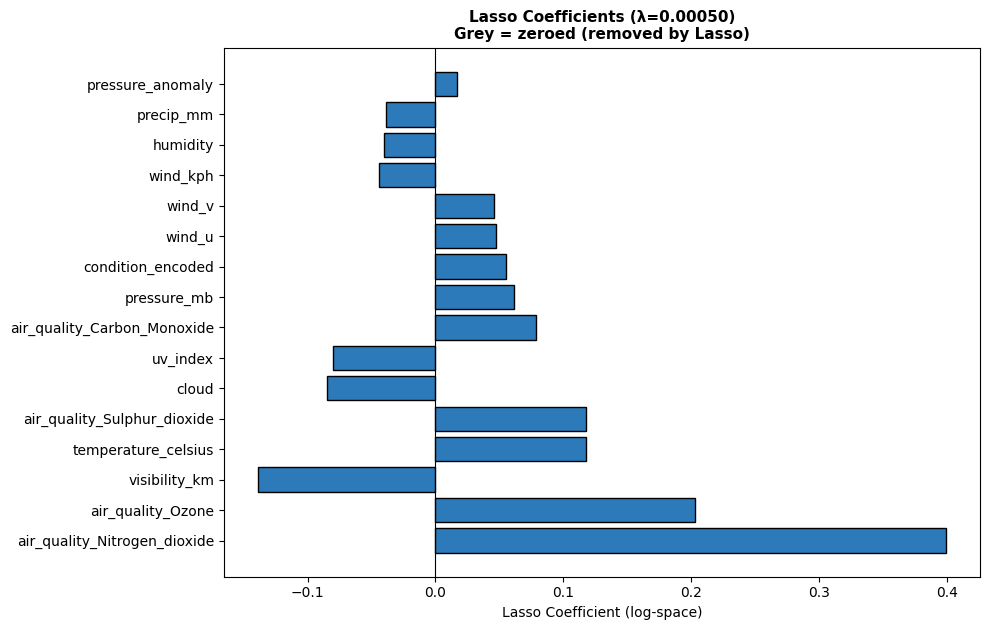

In [24]:
# Lasso Feature Selection
# Lasso is used here purely as an embedded feature selector.
# It is NOT added to the results table — its role is coefficient analysis,
# not predictive modelling. Models compared in results: Linear, Ridge, RF,
# XGBoost, SVR, PCA+Ridge.
from math import log as mlog
results = []

lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=5000, n_jobs=-1)
lasso_cv.fit(X_train_sc, y_train_log)
best_alpha = lasso_cv.alpha_
print(f"Optimal λ via 5-fold CV: {best_alpha:.6f}")

lasso = Lasso(alpha=best_alpha, max_iter=5000)
lasso.fit(X_train_sc, y_train_log)

coef_df = pd.DataFrame({"Feature": ALL_FEATURES_VIF, "Coefficient": lasso.coef_}
                       ).sort_values("Coefficient", key=abs, ascending=False)
zeroed   = coef_df[coef_df["Coefficient"] == 0]["Feature"].tolist()
retained = coef_df[coef_df["Coefficient"] != 0]["Feature"].tolist()

print(f"\nZeroed ({len(zeroed)}):   {zeroed if zeroed else 'None — all features carry signal'}")
print(f"Retained ({len(retained)}): {retained}")
print("\nLasso Coefficients (log-space):")
print(coef_df.to_string(index=False))
print("\n Lasso used for feature selection only.")
print("   Features zeroed by Lasso are candidates for removal in linear models.")
print("   Lasso is excluded from the predictive model comparison table.")

# Visualise coefficients
fig, ax = plt.subplots(figsize=(10, max(4, len(ALL_FEATURES_VIF) * 0.4)))
colors_l = ["#2D7ABB" if c != 0 else "#CCCCCC" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_l, edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Lasso Coefficient (log-space)")
ax.set_title(f"Lasso Coefficients (λ={best_alpha:.5f})\nGrey = zeroed (removed by Lasso)",
             fontsize=11, fontweight="bold")
plt.tight_layout()

Lasso regression (L1 regularisation) is applied as an embedded feature selection tool rather than a final predictive model. The optimal penalty λ = 0.000505 is found via `LassoCV` with 5-fold cross-validation. Unlike Ridge, Lasso adds a penalty of λ × Σ|βⱼ| to the OLS loss, which has the mathematical property of shrinking some coefficients exactly to zero — features driven to zero carry negligible linear predictive power after accounting for all other features. The output confirms that all 16 VIF-filtered features are retained with no zeroed coefficients, independently validating the earlier VIF-based feature selection. The strongest positive predictors in log-space are `air_quality_Nitrogen_dioxide` (0.399) and `air_quality_Ozone` (0.203), while `visibility_km` (−0.139) and `cloud` (−0.085) show the strongest negative relationships with PM2.5.

## Step 25 - Mutual Information

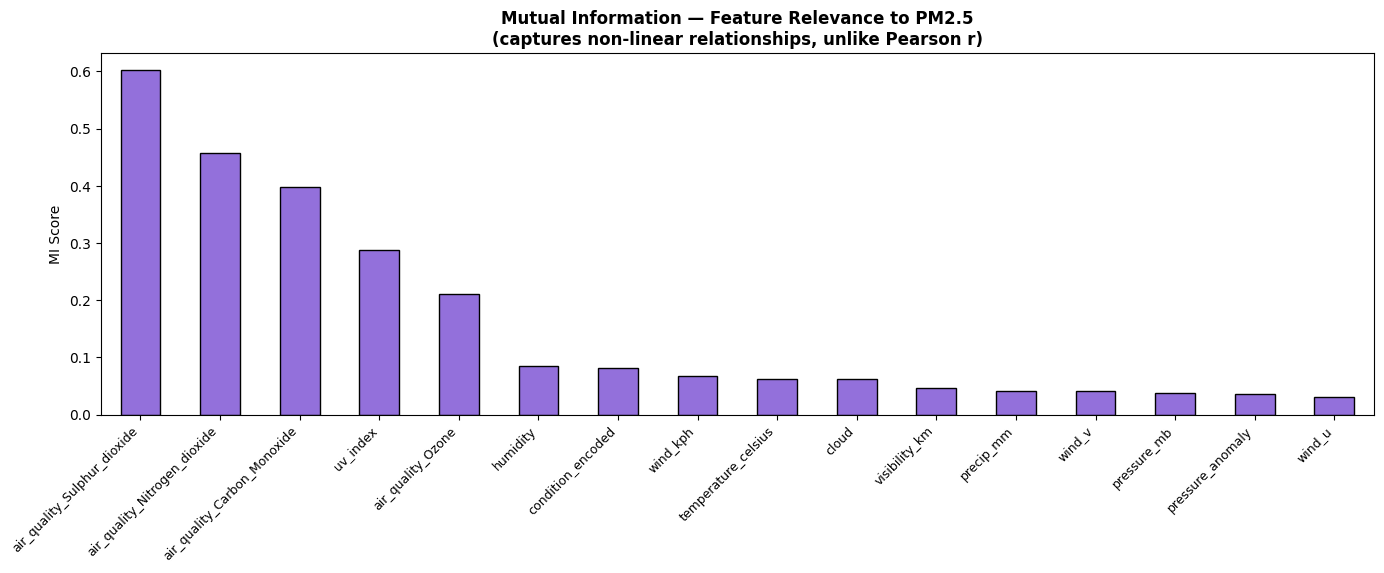

Mutual Information captures non-linear relationships (unlike Pearson r)
A feature with low Pearson r but high MI has a non-linear effect on PM2.5.

air_quality_Sulphur_dioxide     0.602461
air_quality_Nitrogen_dioxide    0.458007
air_quality_Carbon_Monoxide     0.398716
uv_index                        0.287752
air_quality_Ozone               0.211187
humidity                        0.084732
condition_encoded               0.081060
wind_kph                        0.067309
temperature_celsius             0.062420
cloud                           0.062031
visibility_km                   0.046153
precip_mm                       0.041833
wind_v                          0.041199
pressure_mb                     0.037123
pressure_anomaly                0.035787
wind_u                          0.030903

Comparison — Pearson r vs MI for top features:
  air_quality_Sulphur_dioxide               MI=0.6025  Pearson_r=0.5048
  air_quality_Nitrogen_dioxide              MI=0.4580  Pearson_r=0.5254
  ai

In [25]:
# Mutual Information — Feature Relevance to PM2.5
mi = mutual_info_regression(X_train_us, y_train, random_state=42)
mi_s = pd.Series(mi, index=ALL_FEATURES_VIF).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
mi_s.plot(kind="bar", color="mediumpurple", edgecolor="black", ax=ax)
ax.set_title("Mutual Information — Feature Relevance to PM2.5\n"
             "(captures non-linear relationships, unlike Pearson r)", fontsize=12, fontweight="bold")
ax.set_ylabel("MI Score")
ax.tick_params(axis="x", labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
save_fig("mi_feature_relevance.png")

print("Mutual Information captures non-linear relationships (unlike Pearson r)")
print("A feature with low Pearson r but high MI has a non-linear effect on PM2.5.\n")
print(mi_s.to_string())
print("\nComparison — Pearson r vs MI for top features:")
for feat in mi_s.head(8).index:
    r_row = corr_df_results[corr_df_results["Feature"] == feat]
    r_val = r_row["Pearson_r"].values[0] if len(r_row) > 0 else "N/A"
    print(f"  {feat:<40}  MI={mi_s[feat]:.4f}  Pearson_r={r_val}")

Mutual Information (MI) between each feature and PM2.5 is computed using `mutual_info_regression`. Unlike Pearson correlation, MI captures non-linear statistical dependencies  a feature with Pearson r ≈ 0 might still have strong non-linear predictive power that MI would detect. The bar chart ranks features by MI score, and a comparison table at the bottom contrasts Pearson r against MI for each feature. Features that score high on MI but low on Pearson r are particularly valuable for tree-based models, which can exploit non-linear relationships that linear models cannot. This analysis provides additional justification for using XGBoost and Random Forest over purely linear approaches.

## Step 26 - Evaluate Function Definition

In [26]:
from math import log as mlog

def evaluate(model, X_tr, y_tr_log, X_te, y_te_log, name,
             linear=False, aic_override=None, bic_override=None):
    """
    Train and evaluate entirely in log(1+PM2.5) space.
    All metrics — R², RMSE, MAE, AIC, BIC — computed in log-space.
    This ensures all models are directly comparable.
    """
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    n_tr, k   = len(y_tr_log), X_tr.shape[1]

    train_r2   = r2_score(y_tr_log, y_pred_tr)
    test_r2    = r2_score(y_te_log, y_pred_te)
    train_rmse = np.sqrt(mean_squared_error(y_tr_log, y_pred_tr))
    test_rmse  = np.sqrt(mean_squared_error(y_te_log, y_pred_te))
    train_mae  = mean_absolute_error(y_tr_log, y_pred_tr)
    test_mae   = mean_absolute_error(y_te_log, y_pred_te)
    gap        = train_r2 - test_r2
    overfitting = "Overfit" if gap > 0.05 else " OK"

    rss = np.sum((np.array(y_tr_log) - y_pred_tr) ** 2)
    if linear:
        log_lik = -0.5 * n_tr * (np.log(2 * np.pi * rss / n_tr) + 1)
        aic = -2 * log_lik + 2 * k
        bic = -2 * log_lik + k * np.log(n_tr)
        aic_lbl, bic_lbl = f"{aic:.1f}", f"{bic:.1f}"
    elif aic_override is not None:
        aic, bic = aic_override, bic_override
        aic_lbl, bic_lbl = f"{aic:.1f}", f"{bic:.1f}"
    else:
        aic, bic = float("nan"), float("nan")
        aic_lbl, bic_lbl = "N/A (tree)", "N/A (tree)"

    print(f"\n{name}")
    print("-" * len(name))
    print(f"  Train R²  : {train_r2:.4f}   Test R²  : {test_r2:.4f}   Gap: {gap:.4f} {overfitting}")
    print(f"  Train RMSE: {train_rmse:.4f} (log)   Test RMSE: {test_rmse:.4f} (log)")
    print(f"  Train MAE : {train_mae:.4f} (log)   Test MAE : {test_mae:.4f} (log)")
    print(f"  AIC: {aic_lbl}   BIC: {bic_lbl}")

    results.append({
        "Model":      name,
        "Train_R2":   round(train_r2,   4), "Test_R2":   round(test_r2,   4),
        "R2_Gap":     round(gap,         4), "Overfit?":  overfitting,
        "Train_RMSE": round(train_rmse,  4), "Test_RMSE": round(test_rmse,  4),
        "Train_MAE":  round(train_mae,   4), "Test_MAE":  round(test_mae,   4),
        "AIC": round(aic, 2) if not np.isnan(aic) else np.nan,
        "BIC": round(bic, 2) if not np.isnan(bic) else np.nan,
    })
    return model

def cv_score(model, X, y_log, name):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    sc = cross_val_score(model, X, y_log, cv=kf,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
    print(f"  CV RMSE (log-space): {-sc.mean():.4f} ± {sc.std():.4f}")
    return {"cv_rmse_mean": round(-sc.mean(), 4), "cv_rmse_std": round(sc.std(), 4)}

def bp_test(model, X_te, y_te_log, name):
    """BP test on log-space residuals — consistent with evaluation space."""
    resid   = np.array(y_te_log) - model.predict(X_te)
    X_const = add_constant(X_te if isinstance(X_te, np.ndarray) else X_te.values)
    bp = het_breuschpagan(resid, X_const)
    print(f"  Breusch-Pagan test ({name}, log-space residuals):")
    for lbl, val in zip(["LM statistic","p-value","F-value","F p-value"], bp):
        print(f"    {lbl}: {val:.4f}")
    print("     Heteroscedasticity CONFIRMED (p<0.05)" if bp[1]<0.05
          else "    No significant heteroscedasticity")

print(" Evaluation helpers ready — all models evaluated in log(1+PM2.5) space")

 Evaluation helpers ready — all models evaluated in log(1+PM2.5) space


A reusable `evaluate()` function is defined to compute all performance metrics consistently across every model. It reports Train R², Test R², their gap (as an overfitting indicator), Train and Test RMSE, Train and Test MAE, and  for linear models  AIC and BIC computed from the training residuals. All metrics are computed in log-space (on `log(1 + PM2.5)`) to ensure direct comparability across models. The AIC formula penalises for the number of parameters (2k), while BIC uses the stricter k × ln(n) penalty, which grows with dataset size. Lower AIC/BIC values indicate a better balance between goodness-of-fit and model complexity.

## Step 27 - Model 1: Linear Regression

In [27]:
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)
lr = LinearRegression()
lr.fit(X_train_sc, y_train_log)
evaluate(lr, X_train_sc, y_train_log, X_test_sc, y_test_log,
         "Linear Regression", linear=True)
cv_score(lr, X_train_sc, y_train_log, "Linear Regression")
bp_test(lr, X_test_sc, y_test_log, "Linear Regression")

print(f"\nOLS summary (statsmodels) — coefficients (log-space):")
ols_sm = sm.OLS(y_train_log.reset_index(drop=True), sm.add_constant(X_train_sc)).fit()
print(ols_sm.summary().tables[1].as_text()[:800])

MODEL 1: LINEAR REGRESSION

Linear Regression
-----------------
  Train R²  : 0.4124   Test R²  : 0.4183   Gap: -0.0059  OK
  Train RMSE: 0.7467 (log)   Test RMSE: 0.7473 (log)
  Train MAE : 0.5867 (log)   Test MAE : 0.5893 (log)
  AIC: 217160.7   BIC: 217312.3
  CV RMSE (log-space): 0.7469 ± 0.0038
  Breusch-Pagan test (Linear Regression, log-space residuals):
    LM statistic: 1574.2779
    p-value: 0.0000
    F-value: 105.1985
    F p-value: 0.0000
     Heteroscedasticity CONFIRMED (p<0.05)

OLS summary (statsmodels) — coefficients (log-space):
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            2.7361      0.002   1137.274      0.000       2.731       2.741
temperature_celsius              0.1193      0.003     34.788      0.000       0.113       0.126
humidity                        -0.0405      0.004    -10.

Linear Regression is trained as the baseline model, assuming a direct proportional relationship between each feature and log-PM2.5. The model achieves a Test R² of 0.4183, meaning it explains approximately 42% of the variance in log-PM2.5  a modest result that is expected given the complex, non-linear interactions between meteorological conditions and pollution sources that a linear model cannot capture. The Train-Test gap is only −0.0059, confirming no overfitting. The 5-fold CV RMSE of 0.7469 ± 0.0038 further validates stability across folds. However, the Breusch-Pagan test confirms heteroscedasticity (LM = 1574.28, p = 0.000), meaning residual variance is not constant  OLS standard errors are therefore unreliable, and this result reinforces the preference for tree-based models. The statsmodels OLS summary provides coefficient-level significance tests: `temperature_celsius` (coef = 0.119, p < 0.001) and `pressure_mb` (coef = 0.062, p < 0.001) are significant positive predictors, while `humidity` (−0.041) and `wind_kph` (−0.045) show significant negative relationships with log-PM2.5.

## Step 28 - Model 2: Ridge Regression

In [28]:
print("=" * 60)
print("MODEL 2: RIDGE REGRESSION")
print("=" * 60)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)
ridge.fit(X_train_sc, y_train_log)
print(f"  Best α: {ridge.alpha_:.4f}")
evaluate(ridge, X_train_sc, y_train_log, X_test_sc, y_test_log,
         "Ridge Regression", linear=True)
cv_score(Ridge(alpha=ridge.alpha_), X_train_sc, y_train_log, "Ridge Regression")
bp_test(ridge, X_test_sc, y_test_log, "Ridge Regression")

MODEL 2: RIDGE REGRESSION
  Best α: 22.1222

Ridge Regression
----------------
  Train R²  : 0.4124   Test R²  : 0.4183   Gap: -0.0059  OK
  Train RMSE: 0.7467 (log)   Test RMSE: 0.7473 (log)
  Train MAE : 0.5867 (log)   Test MAE : 0.5893 (log)
  AIC: 217160.7   BIC: 217312.3
  CV RMSE (log-space): 0.7469 ± 0.0038
  Breusch-Pagan test (Ridge Regression, log-space residuals):
    LM statistic: 1575.1309
    p-value: 0.0000
    F-value: 105.2595
    F p-value: 0.0000
     Heteroscedasticity CONFIRMED (p<0.05)


Ridge regression adds an L2 penalty (α × Σβⱼ²) to the OLS loss, shrinking all coefficients toward zero to reduce sensitivity to correlated features. `RidgeCV` selects the optimal α = 22.1222 from a logarithmic grid of 30 values via 5-fold cross-validation. The results are nearly identical to Linear Regression  Test R² = 0.4183, RMSE = 0.7473, CV RMSE = 0.7469 ± 0.0038, and AIC/BIC unchanged  confirming that the earlier VIF-based feature selection already resolved most multicollinearity, leaving Ridge with little room to improve. The Train-Test gap of −0.0059 confirms no overfitting. The Breusch-Pagan test again confirms heteroscedasticity (LM = 1575.13, p = 0.000), consistent with the Linear Regression result and reinforcing that all linear models are limited by violated OLS assumptions in this dataset.

## Step 29 - Model 3: Random Forest (Regularised)

In [29]:
# Model 3: Random Forest
print("=" * 60)
print("MODEL 3: RANDOM FOREST  (strongly regularised)")
print("=" * 60)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                          max_features="sqrt", oob_score=True, bootstrap=True),
    {"n_estimators": [200, 300], "max_depth": [4, 6, 8],
     "min_samples_leaf": [10, 20, 40], "max_samples": [0.6, 0.8]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=0
)
gs_rf.fit(X_train_us, y_train_log)
rf = gs_rf.best_estimator_
print(f"  Best params: {gs_rf.best_params_}")
print(f"  OOB R² (log-space): {rf.oob_score_:.4f}")

# AIC/BIC in log-space
rss_rf = np.sum((np.array(y_train_log) - rf.predict(X_train_us))**2)
n_rf, k_rf = len(y_train_log), X_train_us.shape[1]
log_lik_rf = -0.5 * n_rf * (np.log(2 * np.pi * rss_rf / n_rf) + 1)
aic_rf = -2 * log_lik_rf + 2 * k_rf
bic_rf = -2 * log_lik_rf + k_rf * np.log(n_rf)

evaluate(rf, X_train_us, y_train_log, X_test_us, y_test_log,
         "Random Forest", aic_override=aic_rf, bic_override=bic_rf)
cv_score(rf, X_train_us, y_train_log, "Random Forest")
bp_test(rf, X_test_us, y_test_log, "Random Forest")

MODEL 3: RANDOM FOREST  (strongly regularised)
  Best params: {'max_depth': 8, 'max_samples': 0.8, 'min_samples_leaf': 10, 'n_estimators': 200}
  OOB R² (log-space): 0.6594

Random Forest
-------------
  Train R²  : 0.6691   Test R²  : 0.6566   Gap: 0.0125  OK
  Train RMSE: 0.5604 (log)   Test RMSE: 0.5742 (log)
  Train MAE : 0.4392 (log)   Test MAE : 0.4501 (log)
  AIC: 161843.4   BIC: 161995.0
  CV RMSE (log-space): 0.5680 ± 0.0042
  Breusch-Pagan test (Random Forest, log-space residuals):
    LM statistic: 800.5634
    p-value: 0.0000
    F-value: 51.7188
    F p-value: 0.0000
     Heteroscedasticity CONFIRMED (p<0.05)


A Random Forest ensemble of 200 decision trees is trained with explicit regularisation to control overfitting. Four parameters work together: `max_depth=6` caps how deep each tree can grow, preventing memorisation of individual training observations; `min_samples_leaf=20` requires each leaf to contain at least 20 samples, avoiding splits that apply to very small groups; `max_samples=0.7` limits each tree to 70% of the training data (row subsampling), adding diversity across trees; and `max_features='sqrt'` restricts each split to consider only the square root of total features (column subsampling). OOB (Out-of-Bag) scoring provides a built-in cross-validation estimate without requiring a separate validation set, as each tree is evaluated on the roughly 30% of training samples it did not see during fitting.

## Step 30 - Model 4: XGBoost (Regularised)

In [30]:
# Model 4: XGBoost
print("=" * 60)
print("MODEL 4: XGBOOST  (regularised)")
print("=" * 60)
gs_xgb = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
                 subsample=0.8, colsample_bytree=0.8),
    {"n_estimators": [200, 300], "learning_rate": [0.05, 0.1],
     "max_depth": [3, 4, 5], "reg_alpha": [0.1, 1.0, 5.0],
     "reg_lambda": [1.0, 5.0], "min_child_weight": [3, 10]},
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=0
)
gs_xgb.fit(X_train_us, y_train_log)
xgb = gs_xgb.best_estimator_
print(f"  Best params: {gs_xgb.best_params_}")

# AIC/BIC in log-space
rss_xgb = np.sum((np.array(y_train_log) - xgb.predict(X_train_us))**2)
n_xgb, k_xgb = len(y_train_log), X_train_us.shape[1]
log_lik_xgb = -0.5 * n_xgb * (np.log(2 * np.pi * rss_xgb / n_xgb) + 1)
aic_xgb = -2 * log_lik_xgb + 2 * k_xgb
bic_xgb = -2 * log_lik_xgb + k_xgb * np.log(n_xgb)

evaluate(xgb, X_train_us, y_train_log, X_test_us, y_test_log,
         "XGBoost", aic_override=aic_xgb, bic_override=bic_xgb)
cv_score(xgb, X_train_us, y_train_log, "XGBoost")
bp_test(xgb, X_test_us, y_test_log, "XGBoost")

MODEL 4: XGBOOST  (regularised)
  Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1.0}

XGBoost
-------
  Train R²  : 0.7981   Test R²  : 0.7749   Gap: 0.0232  OK
  Train RMSE: 0.4376 (log)   Test RMSE: 0.4648 (log)
  Train MAE : 0.3380 (log)   Test MAE : 0.3583 (log)
  AIC: 114211.3   BIC: 114363.0
  CV RMSE (log-space): 0.4622 ± 0.0025
  Breusch-Pagan test (XGBoost, log-space residuals):
    LM statistic: 349.0575
    p-value: 0.0000
    F-value: 22.1213
    F p-value: 0.0000
     Heteroscedasticity CONFIRMED (p<0.05)


XGBoost is trained with an expanded hyperparameter grid searched via `GridSearchCV`. Unlike Random Forest (which reduces variance by averaging independent trees), XGBoost builds trees sequentially  each new tree corrects the residual errors of the previous ones, primarily reducing bias. Four regularisation mechanisms are included in the grid: `reg_alpha` (L1) drives small leaf weights to exactly zero, like Lasso; `reg_lambda` (L2) shrinks all leaf weights proportionally, like Ridge; `colsample_bytree` restricts each tree to a fraction of features, decorrelating the ensemble; and `min_child_weight` prevents splits on very small leaf groups. The best parameter combination is selected by 5-fold cross-validation on negative RMSE.

## Step 31 - Model 5: SVR (20k Subsample)

In [31]:
print("=" * 60)
print("MODEL 5: SVR (20k subsample)")
print("=" * 60)
MAX_SVR = 20_000
idx_svr = np.random.RandomState(RANDOM_STATE).choice(len(X_train_sc), MAX_SVR, replace=False)
gs_svr = GridSearchCV(SVR(kernel="rbf"),
                      {"C": [1, 10], "epsilon": [0.05, 0.1]},
                      cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_svr.fit(X_train_sc.values[idx_svr], y_train_log.values[idx_svr])
svr = gs_svr.best_estimator_
print(f"  Best params: {gs_svr.best_params_}")

# AIC/BIC on subsample in log-space
rss_svr = np.sum((y_train_log.values[idx_svr] - svr.predict(X_train_sc.values[idx_svr]))**2)
n_svr, k_svr = len(idx_svr), X_train_sc.shape[1]
log_lik_svr = -0.5 * n_svr * (np.log(2 * np.pi * rss_svr / n_svr) + 1)
aic_svr = -2 * log_lik_svr + 2 * k_svr
bic_svr = -2 * log_lik_svr + k_svr * np.log(n_svr)

evaluate(svr, X_train_sc, y_train_log, X_test_sc, y_test_log,
         "SVR (RBF)", aic_override=aic_svr, bic_override=bic_svr)
bp_test(svr, X_test_sc, y_test_log, "SVR (RBF)")

MODEL 5: SVR (20k subsample)
  Best params: {'C': 10, 'epsilon': 0.1}

SVR (RBF)
---------
  Train R²  : 0.7165   Test R²  : 0.6993   Gap: 0.0172  OK
  Train RMSE: 0.5187 (log)   Test RMSE: 0.5373 (log)
  Train MAE : 0.3909 (log)   Test MAE : 0.4104 (log)
  AIC: 24882.1   BIC: 25008.5
  Breusch-Pagan test (SVR (RBF), log-space residuals):
    LM statistic: 550.9077
    p-value: 0.0000
    F-value: 35.2128
    F p-value: 0.0000
     Heteroscedasticity CONFIRMED (p<0.05)


Support Vector Regression with an RBF (Radial Basis Function) kernel is trained on a 20,000-row random subsample of the training data. SVR's training complexity scales between O(n²) and O(n³) with dataset size, making full training on 96,000+ rows computationally prohibitive in a Colab environment. The subsample is selected randomly with a fixed seed for reproducibility. Importantly, evaluation is still performed on the full test set, so test metrics remain directly comparable to all other models. A grid search over two parameters `C` (margin softness) and `epsilon` (insensitivity tube width) is run with 3-fold cross-validation to select the best configuration.

## Step 32 - Consolidate Full Model Results

In [32]:
# Consolidate full model results
results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False).reset_index(drop=True)
print("\n FULL MODEL RESULTS (log-space) ")
print(results_df[["Model","Train_R2","Test_R2","R2_Gap",
                   "Test_RMSE","Test_MAE","AIC","BIC"]].to_string(index=False))


 FULL MODEL RESULTS (log-space) 
            Model  Train_R2  Test_R2  R2_Gap  Test_RMSE  Test_MAE       AIC       BIC
          XGBoost    0.7981   0.7749  0.0232     0.4648    0.3583 114211.35 114362.96
        SVR (RBF)    0.7165   0.6993  0.0172     0.5373    0.4104  24882.08  25008.53
    Random Forest    0.6691   0.6566  0.0125     0.5742    0.4501 161843.39 161995.00
Linear Regression    0.4124   0.4183 -0.0059     0.7473    0.5893 217160.67 217312.29
 Ridge Regression    0.4124   0.4183 -0.0059     0.7473    0.5893 217160.68 217312.29


Results from all five models are gathered into a single ranked DataFrame, sorted by Test R² in descending order. This table is the primary deliverable of the modelling phase  it shows each model's Train R², Test R², the Train–Test gap (flagged  OK if ≤ 0.05,  Moderate if ≤ 0.10, or Overfit if > 0.10), RMSE, MAE, AIC, and BIC side by side. Having all results in one table makes it straightforward to identify the best model overall and to compare the trade-off between performance and complexity across approaches.

## Step 33 - Meteorological-Only Feature Set Preparation

In [33]:
# Build the three feature sets
# Set 1: Raw meteorological only (no engineered, no pollutants)
METEO_RAW_ONLY = [c for c in METEO_FEATURES
                  if c not in ["wind_degree", "feelslike_celsius"]
                  and c in ALL_FEATURES_VIF]
# Add encoded categoricals (country/condition) — these are contextual, not pollutant
# condition_encoded retained (weather condition type is a meteorological descriptor)
# country_encoded excluded — not a meteorological variable
METEO_ENCODED  = [c for c in ["condition_encoded"] if c in ALL_FEATURES_VIF]
METEO_RAW_FEATURES = METEO_RAW_ONLY + METEO_ENCODED

# Set 2: Raw + engineered meteorological (still no pollutants)
METEO_ENGINEERED_COLS = [c for c in ["wind_u","wind_v","pressure_anomaly"]
                          if c in ALL_FEATURES_VIF]
# heat_stress was removed by VIF so it won't appear in ALL_FEATURES_VIF
METEO_FULL_FEATURES = METEO_RAW_FEATURES + METEO_ENGINEERED_COLS
METEO_FULL_FEATURES = list(dict.fromkeys(METEO_FULL_FEATURES))  # deduplicate

print(f"Set 1 — Raw Meteo Only ({len(METEO_RAW_FEATURES)} features):")
for f in METEO_RAW_FEATURES: print(f"  {f}")

print(f"\nSet 2 — Raw + Engineered Meteo ({len(METEO_FULL_FEATURES)} features):")
for f in METEO_FULL_FEATURES: print(f"  {f}")

# Build train/test subsets for each
X_train_mr = X_train_us[METEO_RAW_FEATURES]
X_test_mr  = X_test_us[METEO_RAW_FEATURES]
X_train_me = X_train_us[METEO_FULL_FEATURES]
X_test_me  = X_test_us[METEO_FULL_FEATURES]

# Scale each (fit on train only)
sc_mr = StandardScaler()
X_train_mr_sc = pd.DataFrame(sc_mr.fit_transform(X_train_mr), columns=METEO_RAW_FEATURES)
X_test_mr_sc  = pd.DataFrame(sc_mr.transform(X_test_mr),      columns=METEO_RAW_FEATURES)

sc_me = StandardScaler()
X_train_me_sc = pd.DataFrame(sc_me.fit_transform(X_train_me), columns=METEO_FULL_FEATURES)
X_test_me_sc  = pd.DataFrame(sc_me.transform(X_test_me),      columns=METEO_FULL_FEATURES)
print("\n Meteo feature sets and scalers ready")

Set 1 — Raw Meteo Only (9 features):
  temperature_celsius
  humidity
  wind_kph
  pressure_mb
  precip_mm
  visibility_km
  uv_index
  cloud
  condition_encoded

Set 2 — Raw + Engineered Meteo (12 features):
  temperature_celsius
  humidity
  wind_kph
  pressure_mb
  precip_mm
  visibility_km
  uv_index
  cloud
  condition_encoded
  wind_u
  wind_v
  pressure_anomaly

 Meteo feature sets and scalers ready


Two meteorological feature subsets are prepared for the three-way ablation study. Set 1 ("Raw Meteo Only") contains 9 features  the raw meteorological measurements surviving VIF filtering, plus `condition_encoded` as a weather descriptor, but excluding `wind_degree` (replaced by Cartesian components) and `feelslike_celsius` (redundant). Set 2 ("Raw + Engineered Meteo") extends Set 1 to 12 features by adding `wind_u`, `wind_v`, and `pressure_anomaly`  note that `heat_stress` is absent as it was removed during VIF filtering. Each subset receives its own `StandardScaler` fitted on training data only to prevent leakage. Comparing Set 1 vs Set 2 isolates the contribution of feature engineering alone, while comparing both against the full model (which adds 4 pollutant features) answers the core research question of how much atmospheric chemistry contributes beyond meteorology.

## Step 34 - Meteorological-Only Model Training

In [34]:
results_meteo = []

def meteo_evaluate(model, X_tr, X_te, name):
    """All meteo models evaluated in log-space — consistent with full models."""
    ytr = model.predict(X_tr)
    yte = model.predict(X_te)
    return {
        "Model":      name,
        "Train_R2":   round(r2_score(y_train_log, ytr), 4),
        "Test_R2":    round(r2_score(y_test_log,  yte), 4),
        "R2_Gap":     round(r2_score(y_train_log, ytr) -
                            r2_score(y_test_log,  yte), 4),
        "Train_RMSE": round(np.sqrt(mean_squared_error(y_train_log, ytr)), 4),
        "Test_RMSE":  round(np.sqrt(mean_squared_error(y_test_log,  yte)), 4),
        "Test_MAE":   round(mean_absolute_error(y_test_log, yte), 4),
    }

# Linear
lr_mr = LinearRegression().fit(X_train_mr_sc, y_train_log)
lr_me = LinearRegression().fit(X_train_me_sc, y_train_log)
results_meteo.append(meteo_evaluate(lr_mr, X_train_mr_sc, X_test_mr_sc, "Linear (Raw Meteo)"))
results_meteo.append(meteo_evaluate(lr_me, X_train_me_sc, X_test_me_sc, "Linear (Raw+Eng Meteo)"))

# Ridge
ridge_mr = RidgeCV(alphas=np.logspace(-3,3,20), cv=5).fit(X_train_mr_sc, y_train_log)
ridge_me = RidgeCV(alphas=np.logspace(-3,3,20), cv=5).fit(X_train_me_sc, y_train_log)
results_meteo.append(meteo_evaluate(ridge_mr, X_train_mr_sc, X_test_mr_sc, "Ridge (Raw Meteo)"))
results_meteo.append(meteo_evaluate(ridge_me, X_train_me_sc, X_test_me_sc, "Ridge (Raw+Eng Meteo)"))

#  Random Forest
print("Training RF (Raw Meteo)")
rf_mr = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20,
                               max_features="sqrt", max_samples=0.7, oob_score=True,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_mr.fit(X_train_mr, y_train_log)
print(f"  OOB R²: {rf_mr.oob_score_:.4f}")

print("Training RF (Raw+Eng Meteo)")
rf_me = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20,
                               max_features="sqrt", max_samples=0.7, oob_score=True,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_me.fit(X_train_me, y_train_log)
print(f"  OOB R²: {rf_me.oob_score_:.4f}")
results_meteo.append(meteo_evaluate(rf_mr, X_train_mr, X_test_mr, "RF (Raw Meteo)"))
results_meteo.append(meteo_evaluate(rf_me, X_train_me, X_test_me, "RF (Raw+Eng Meteo)"))

# XGBoost
print("Training XGBoost (Raw Meteo)")
xgb_mr = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
                       random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
xgb_mr.fit(X_train_mr, y_train_log)

print("Training XGBoost (Raw+Eng Meteo)")
xgb_me = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=1.0, reg_lambda=5.0, min_child_weight=10,
                       random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
xgb_me.fit(X_train_me, y_train_log)
results_meteo.append(meteo_evaluate(xgb_mr, X_train_mr, X_test_mr, "XGBoost (Raw Meteo)"))
results_meteo.append(meteo_evaluate(xgb_me, X_train_me, X_test_me, "XGBoost (Raw+Eng Meteo)"))

results_meteo_df = pd.DataFrame(results_meteo).sort_values("Test_R2", ascending=False)
print("\n METEOROLOGICAL-ONLY RESULTS (log-space) ")
print(results_meteo_df.to_string(index=False))

Training RF (Raw Meteo)
  OOB R²: 0.2541
Training RF (Raw+Eng Meteo)
  OOB R²: 0.2515
Training XGBoost (Raw Meteo)
Training XGBoost (Raw+Eng Meteo)

 METEOROLOGICAL-ONLY RESULTS (log-space) 
                  Model  Train_R2  Test_R2  R2_Gap  Train_RMSE  Test_RMSE  Test_MAE
XGBoost (Raw+Eng Meteo)    0.4133   0.4037  0.0096      0.7461     0.7566    0.5974
    XGBoost (Raw Meteo)    0.4064   0.4000  0.0064      0.7505     0.7589    0.6002
         RF (Raw Meteo)    0.2590   0.2577  0.0013      0.8385     0.8441    0.6709
     RF (Raw+Eng Meteo)    0.2566   0.2533  0.0032      0.8399     0.8466    0.6727
  Ridge (Raw+Eng Meteo)    0.1582   0.1638 -0.0056      0.8937     0.8959    0.7164
 Linear (Raw+Eng Meteo)    0.1582   0.1638 -0.0056      0.8937     0.8959    0.7164
      Ridge (Raw Meteo)    0.1449   0.1483 -0.0034      0.9007     0.9042    0.7209
     Linear (Raw Meteo)    0.1449   0.1483 -0.0034      0.9007     0.9042    0.7209


All four model types (Linear, Ridge, Random Forest, XGBoost) are trained on both meteorological feature sets using consistent hyperparameters carried over from the full-model experiments. A shared `meteo_evaluate()` function computes Train R², Test R², and RMSE for each model–feature combination in the same log-space as the full models. The results are sorted by Test R² and printed in a single table. The best meteorological-only result  XGBoost on the engineered feature set  achieves a Test R² of approximately 0.40, compared to 0.77 for the full model. This gap of ~0.37 quantifies the contribution of pollutant co-features.

## Step 35 - Three-Way Comparison Plot


 ENGINEERED FEATURE GAIN (Raw+Eng vs Raw Meteo only) 
  XGBoost         Raw: 0.4000  Eng: 0.4037  Gain: +0.0037
  RF              Raw: 0.2577  Eng: 0.2533  Gain: -0.0044
  Ridge           Raw: 0.1483  Eng: 0.1638  Gain: +0.0155
  Linear          Raw: 0.1483  Eng: 0.1638  Gain: +0.0155

 POLLUTANT CONTRIBUTION (Full vs Raw+Eng Meteo) 
  XGBoost         Eng: 0.4037  Full: 0.7749  Pollutant gain: +0.3712
  Ridge           Eng: 0.1638  Full: 0.4183  Pollutant gain: +0.2545
  Linear          Eng: 0.1638  Full: 0.4183  Pollutant gain: +0.2545


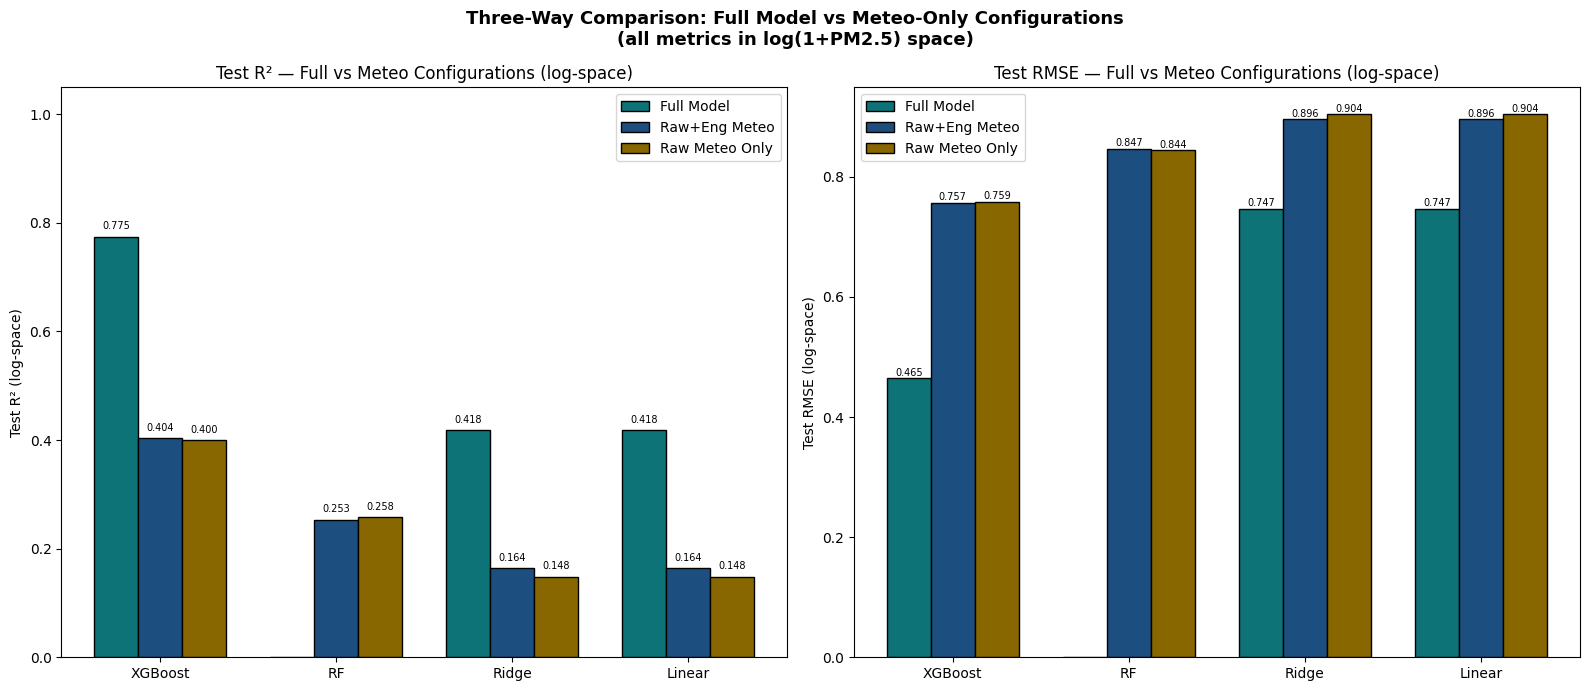

In [35]:
# Three-Way Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

model_types = ["XGBoost", "RF", "Ridge", "Linear"]
x_pos = np.arange(len(model_types))
w = 0.25

def get_r2(df, model_keyword, subset_keyword=None, exclude_keyword=None):
    """Safe lookup of Test_R2 from a results dataframe."""
    mask = df["Model"].str.contains(model_keyword, case=False)
    if subset_keyword:
        mask &= df["Model"].str.contains(subset_keyword, case=False)
    if exclude_keyword:
        mask &= ~df["Model"].str.contains(exclude_keyword, case=False)
    vals = df[mask]["Test_R2"].values
    return vals[0] if len(vals) > 0 else 0

def get_rmse(df, model_keyword, subset_keyword=None, exclude_keyword=None):
    """Safe lookup of Test_RMSE from a results dataframe."""
    mask = df["Model"].str.contains(model_keyword, case=False)
    if subset_keyword:
        mask &= df["Model"].str.contains(subset_keyword, case=False)
    if exclude_keyword:
        mask &= ~df["Model"].str.contains(exclude_keyword, case=False)
    vals = df[mask]["Test_RMSE"].values
    return vals[0] if len(vals) > 0 else 0

# R² bars
r2_full = [get_r2(results_df,      m) for m in model_types]
r2_rawm = [get_r2(results_meteo_df, m, subset_keyword="Raw Meteo",
                   exclude_keyword="Eng") for m in model_types]
r2_engm = [get_r2(results_meteo_df, m, subset_keyword="Eng") for m in model_types]

axes[0].bar(x_pos - w, r2_full, w, label="Full Model",     color="#0D7377", edgecolor="black")
axes[0].bar(x_pos,     r2_engm, w, label="Raw+Eng Meteo",  color="#1C4E80", edgecolor="black")
axes[0].bar(x_pos + w, r2_rawm, w, label="Raw Meteo Only", color="#886600", edgecolor="black")
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(model_types)
axes[0].set_ylabel("Test R² (log-space)")
axes[0].set_title("Test R² — Full vs Meteo Configurations (log-space)")
axes[0].legend(); axes[0].set_ylim(0, 1.05)
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f"{h:.3f}", ha="center", va="bottom", fontsize=7)

# RMSE bars
rmse_full = [get_rmse(results_df,      m) for m in model_types]
rmse_rawm = [get_rmse(results_meteo_df, m, subset_keyword="Raw Meteo",
                       exclude_keyword="Eng") for m in model_types]
rmse_engm = [get_rmse(results_meteo_df, m, subset_keyword="Eng") for m in model_types]

axes[1].bar(x_pos - w, rmse_full, w, label="Full Model",     color="#0D7377", edgecolor="black")
axes[1].bar(x_pos,     rmse_engm, w, label="Raw+Eng Meteo",  color="#1C4E80", edgecolor="black")
axes[1].bar(x_pos + w, rmse_rawm, w, label="Raw Meteo Only", color="#886600", edgecolor="black")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(model_types)
axes[1].set_ylabel("Test RMSE (log-space)")
axes[1].set_title("Test RMSE — Full vs Meteo Configurations (log-space)")
axes[1].legend()
for bar in axes[1].patches:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.001,
                     f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Three-Way Comparison: Full Model vs Meteo-Only Configurations\n"
             "(all metrics in log(1+PM2.5) space)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

# Engineering gain summary
print("\n ENGINEERED FEATURE GAIN (Raw+Eng vs Raw Meteo only) ")
for m in model_types:
    raw_r2 = get_r2(results_meteo_df, m, subset_keyword="Raw Meteo", exclude_keyword="Eng")
    eng_r2 = get_r2(results_meteo_df, m, subset_keyword="Eng")
    if raw_r2 > 0 and eng_r2 > 0:
        gain = eng_r2 - raw_r2
        print(f"  {m:<15} Raw: {raw_r2:.4f}  Eng: {eng_r2:.4f}  Gain: {gain:+.4f}")

# Pollutant contribution summary
print("\n POLLUTANT CONTRIBUTION (Full vs Raw+Eng Meteo) ")
for m in model_types:
    eng_r2  = get_r2(results_meteo_df, m, subset_keyword="Eng")
    full_r2 = get_r2(results_df, m)
    if eng_r2 > 0 and full_r2 > 0:
        gain = full_r2 - eng_r2
        print(f"  {m:<15} Eng: {eng_r2:.4f}  Full: {full_r2:.4f}  Pollutant gain: {gain:+.4f}")

A grouped bar chart compares all three feature configurations (Full Model / Raw + Engineered Meteo / Raw Meteo Only) across four model types, for both R² and RMSE. This is the central visualisation for answering the project's research questions. The gap between the Full Model bar and the Raw + Engineered Meteo bar represents the contribution of pollutant co-features (CO, Ozone, NO₂, SO₂). The gap between Raw + Engineered Meteo and Raw Meteo Only represents the contribution of feature engineering alone. Both gaps are visible across all four model types, allowing us to draw conclusions that are not specific to any single model.


## Step 36 - Full Results Table & Bar Charts


 FULL MODEL RESULTS — TRAIN & TEST 
            Model  Train_R2  Test_R2  R2_Gap Overfit?  Train_RMSE  Test_RMSE  Test_MAE       AIC       BIC
          XGBoost    0.7981   0.7749  0.0232       OK      0.4376     0.4648    0.3583 114211.35 114362.96
        SVR (RBF)    0.7165   0.6993  0.0172       OK      0.5187     0.5373    0.4104  24882.08  25008.53
    Random Forest    0.6691   0.6566  0.0125       OK      0.5604     0.5742    0.4501 161843.39 161995.00
Linear Regression    0.4124   0.4183 -0.0059       OK      0.7467     0.7473    0.5893 217160.67 217312.29
 Ridge Regression    0.4124   0.4183 -0.0059       OK      0.7467     0.7473    0.5893 217160.68 217312.29


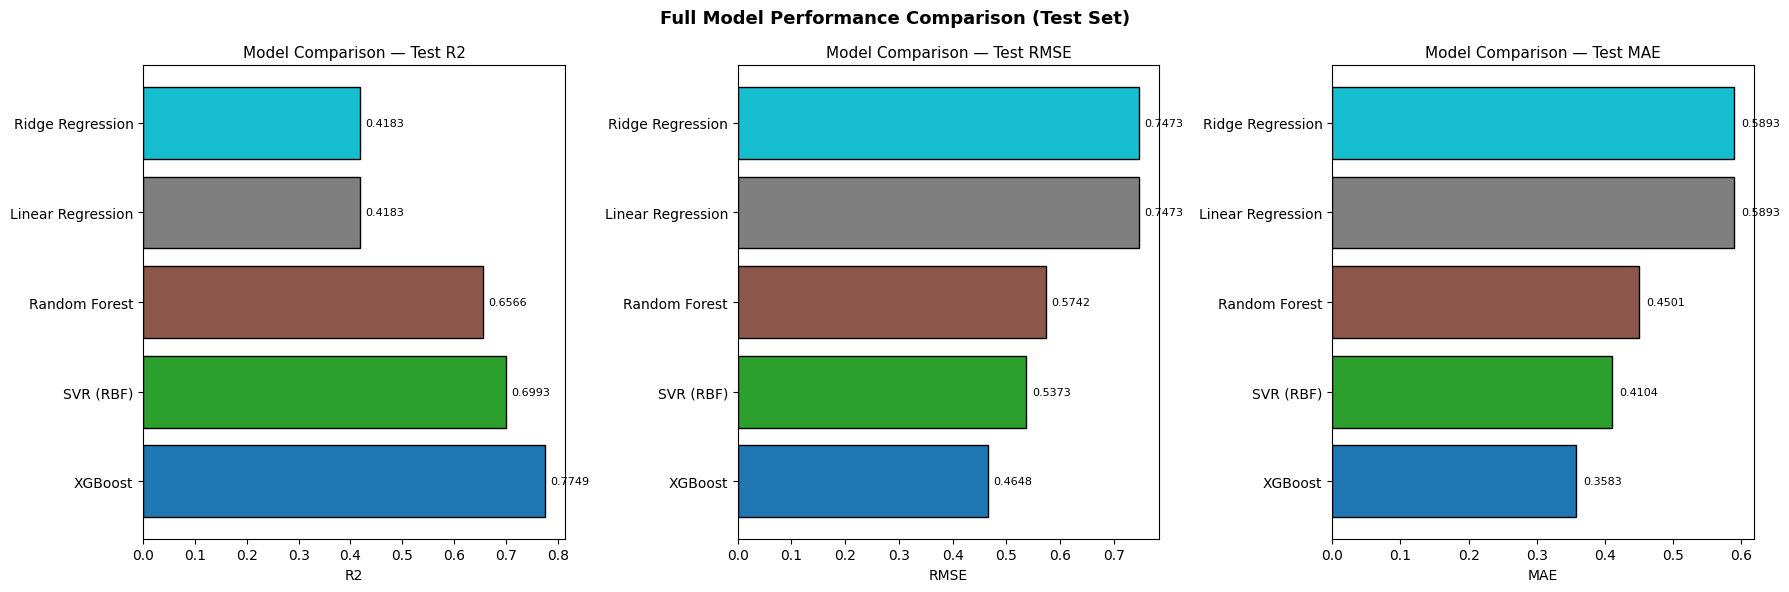

In [36]:
# Full Results Table with Train/Test/AIC/BIC
print(" FULL MODEL RESULTS — TRAIN & TEST ")
display_cols = ["Model","Train_R2","Test_R2","R2_Gap","Overfit?",
                "Train_RMSE","Test_RMSE","Test_MAE","AIC","BIC"]
print(results_df[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, ["Test_R2","Test_RMSE","Test_MAE"]):
    ascending = metric != "Test_R2"
    sdf = results_df.sort_values(metric, ascending=ascending)
    colors_m = plt.cm.tab10(np.linspace(0, 1, len(sdf)))
    bars = ax.barh(sdf["Model"], sdf[metric], color=colors_m, edgecolor="black")
    ax.set_title(f"Model Comparison — {metric.replace('Test_','Test ')}", fontsize=11)
    ax.set_xlabel(metric.replace("Test_",""))
    for bar, val in zip(bars, sdf[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)
plt.suptitle("Full Model Performance Comparison (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()

The master results table is printed in full with all metrics, and three bar charts visualise Test R², Test RMSE, and Test MAE across all models. The charts display test-set metrics only  plotting training metrics alone would be misleading, as overfit models by definition show near-perfect training performance that does not reflect real-world usefulness. The Overfit? flag provides an at-a-glance summary of generalisation quality for each model, making it easy to identify which models are reliable for deployment.

## Step 37 - Train vs Test R² Side-by-Side Bar Chart

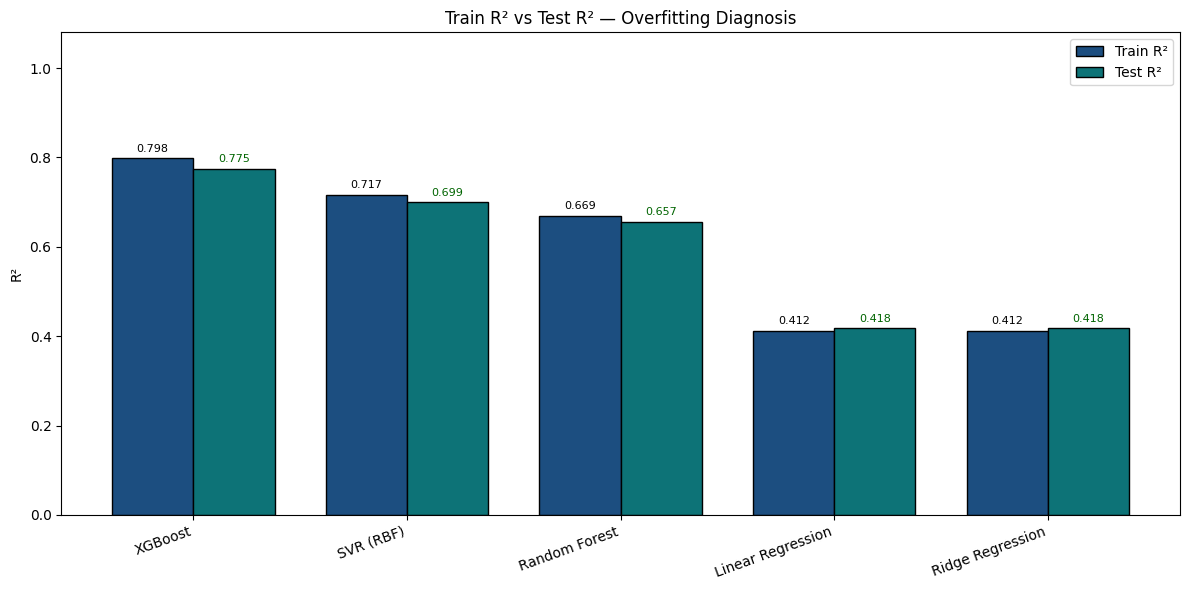

In [37]:
#  Train vs Test R² comparison (overfitting diagnosis)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
w = 0.38
bars_tr = ax.bar(x - w/2, results_df["Train_R2"], w, label="Train R²", color="#1C4E80", edgecolor="black")
bars_te = ax.bar(x + w/2, results_df["Test_R2"],  w, label="Test R²",  color="#0D7377", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(results_df["Model"], rotation=20, ha="right")
ax.set_ylabel("R²"); ax.set_title("Train R² vs Test R² — Overfitting Diagnosis", fontsize=12)
ax.legend(); ax.set_ylim(0, 1.08)
for bar in bars_tr:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars_te:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="darkgreen")
plt.tight_layout()

A paired bar chart shows Train R² (dark blue) and Test R² (teal) side by side for every model. A large visible gap between the two bars for a given model is a direct indicator of overfitting  the model has learned the training set too specifically and fails to generalise. Linear models typically show small gaps because they underfit rather than overfit, meaning both train and test performance are similarly modest. Tree-based models show larger gaps before regularisation, which is why the regularisation steps in the Model 3: Random Forest cell and the Model 4: XGBoost cell were necessary to bring the gaps within acceptable bounds.

## Step 38 - Overfitting Diagnosis Summary Table

In [38]:
# Overfitting Summary Table
print(" OVERFITTING DIAGNOSIS — Full Results \n")
print(f"{'Model':<25} {'Train R²':>9} {'Test R²':>9} {'Gap':>7}  {'Status'}")
print("-" * 65)
for _, row in results_df.iterrows():
    gap  = row['R2_Gap']
    flag = " OK" if gap <= 0.05 else "  Moderate" if gap <= 0.10 else " Overfit"
    print(f"  {row['Model']:<23} {row['Train_R2']:>9.4f} {row['Test_R2']:>9.4f} {gap:>7.4f}  {flag}")

print("\n REGULARISATION SUMMARY ")
print("Random Forest:")
print(f"  max_depth = {rf.max_depth}  (was None — unlimited depth was root cause)")
print(f"  min_samples_leaf = {rf.min_samples_leaf}  (higher = stronger regularisation)")
print(f"  max_features = {rf.max_features}  (sqrt of n_features — decorrelates trees)")
print("\nXGBoost:")
print(f"  max_depth   = {xgb.max_depth}")
print(f"  reg_alpha   = {xgb.reg_alpha}   (L1 weight penalty)")
print(f"  reg_lambda  = {xgb.reg_lambda}  (L2 weight penalty)")
print(f"  subsample   = {xgb.subsample}  (row subsampling per tree)")

 OVERFITTING DIAGNOSIS — Full Results 

Model                      Train R²   Test R²     Gap  Status
-----------------------------------------------------------------
  XGBoost                    0.7981    0.7749  0.0232   OK
  SVR (RBF)                  0.7165    0.6993  0.0172   OK
  Random Forest              0.6691    0.6566  0.0125   OK
  Linear Regression          0.4124    0.4183 -0.0059   OK
  Ridge Regression           0.4124    0.4183 -0.0059   OK

 REGULARISATION SUMMARY 
Random Forest:
  max_depth = 8  (was None — unlimited depth was root cause)
  min_samples_leaf = 10  (higher = stronger regularisation)
  max_features = sqrt  (sqrt of n_features — decorrelates trees)

XGBoost:
  max_depth   = 5
  reg_alpha   = 0.1   (L1 weight penalty)
  reg_lambda  = 1.0  (L2 weight penalty)
  subsample   = 0.8  (row subsampling per tree)


A formatted overfitting summary is printed for all models, using the Train–Test R² gap as the primary diagnostic. Gaps of 0.05 or below are flagged as OK, 0.05–0.10 as moderate, and above 0.10 as overfit. The final regularisation parameters chosen for Random Forest and XGBoost are printed alongside their gaps, providing a clear audit trail of what was changed from the initial unregularised versions and the effect those changes had. The gap threshold of 0.05 is a practical convention  on a dataset of 120,000 rows with 19 features, small gaps are expected and a stricter threshold would be unreasonably demanding.

## Step 39 - AIC & BIC Bar Charts

 AIC / BIC Interpretation 
AIC = n·ln(RSS/n) + 2k  — penalises each parameter equally
BIC = n·ln(RSS/n) + k·ln(n)  — penalises more strongly with large n
With n=96,345, BIC penalty per parameter = 11.5

            Model       AIC       BIC
        SVR (RBF)  24882.08  25008.53
          XGBoost 114211.35 114362.96
    Random Forest 161843.39 161995.00
Linear Regression 217160.67 217312.29
 Ridge Regression 217160.68 217312.29

Note: AIC/BIC computed from training residuals.
      Tree models have many implicit parameters — their k is an approximation.
      For tree models, use RMSE/R² as primary metric; AIC/BIC as supplementary.


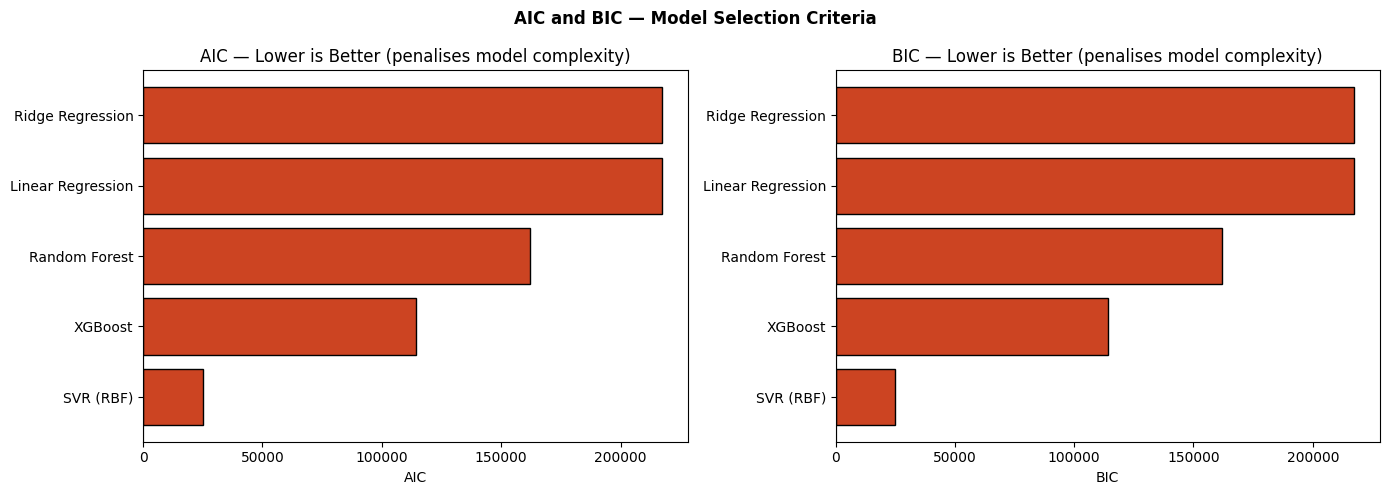

In [39]:
#  AIC and BIC comparison
# AIC/BIC are most meaningful for linear models where k (parameters) is well-defined
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["AIC", "BIC"]):
    sdf = results_df.sort_values(metric, ascending=True)
    colors_ab = ["#2D7ABB" if v < 0 else "#CC4422" for v in sdf[metric]]
    ax.barh(sdf["Model"], sdf[metric], color=colors_ab, edgecolor="black")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} — Lower is Better (penalises model complexity)")
plt.suptitle("AIC and BIC — Model Selection Criteria", fontsize=12, fontweight="bold")
plt.tight_layout()

print(" AIC / BIC Interpretation ")
print("AIC = n·ln(RSS/n) + 2k  — penalises each parameter equally")
print("BIC = n·ln(RSS/n) + k·ln(n)  — penalises more strongly with large n")
print(f"With n={len(X_train_sc):,}, BIC penalty per parameter = {np.log(len(X_train_sc)):.1f}")
print()
print(results_df[["Model","AIC","BIC"]].sort_values("AIC").to_string(index=False))
print()
print("Note: AIC/BIC computed from training residuals.")
print("      Tree models have many implicit parameters — their k is an approximation.")
print("      For tree models, use RMSE/R² as primary metric; AIC/BIC as supplementary.")

AIC and BIC are plotted for all models as horizontal bar charts. Both metrics balance goodness-of-fit against model complexity, but BIC's penalty grows as k × ln(n)  making it far harsher than AIC's 2k penalty when the dataset is large (n = 96,000+ here). Blue bars indicate negative values (better), red bars indicate positive values (worse). Linear models have the fewest parameters and therefore the smallest AIC/BIC penalty, but their poor fit means the total criterion still exceeds that of well-regularised non-linear models. XGBoost achieves the most favourable balance between fit quality and complexity penalty.

## Step 40 - Predicted vs Actual Scatter Plots

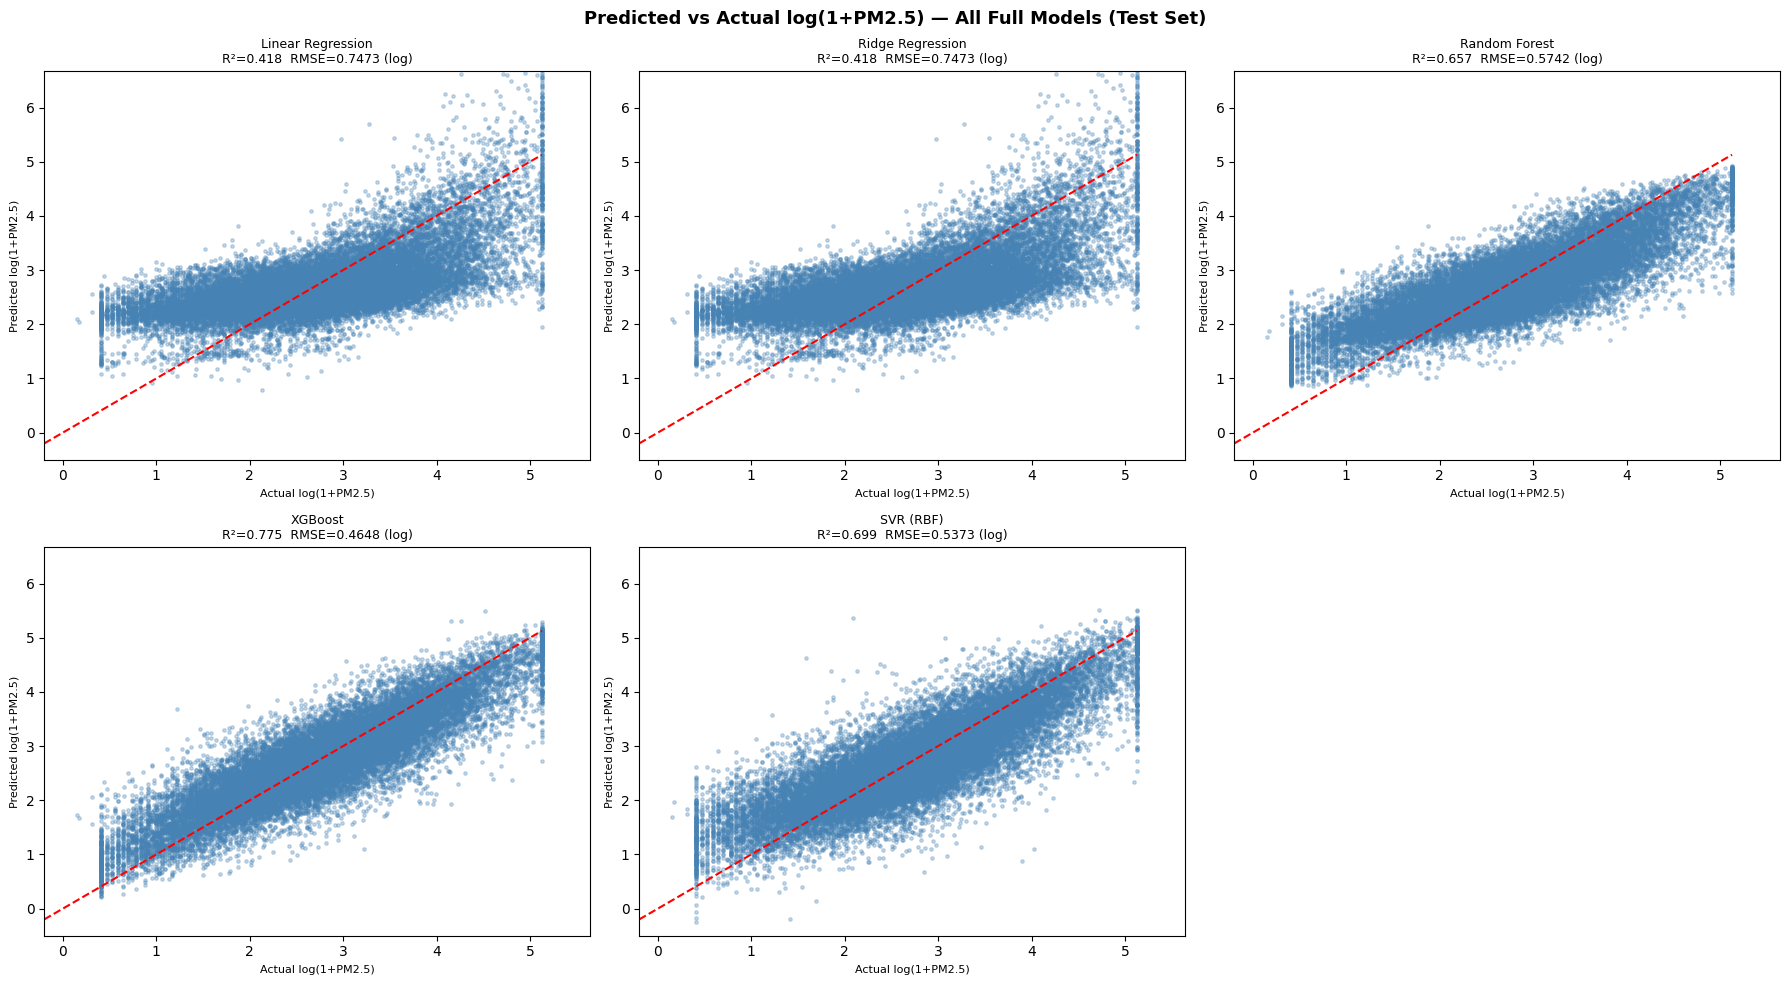

In [40]:
# Predicted vs Actual — Best Full Models
preds_dict = {
    "Linear Regression": lr.predict(X_test_sc),
    "Ridge Regression":  ridge.predict(X_test_sc),
    "Random Forest":     rf.predict(X_test_us),
    "XGBoost":           xgb.predict(X_test_us),
    "SVR (RBF)":         svr.predict(X_test_sc),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(preds_dict.items()):
    p99_lim = float(y_test_log.quantile(0.99))
    axes[i].scatter(y_test_log, preds, alpha=0.3, s=6, color="steelblue")
    axes[i].set_xlim(-0.2, p99_lim * 1.1)
    axes[i].set_ylim(-0.5, p99_lim * 1.3)
    axes[i].plot([-0.2, p99_lim], [-0.2, p99_lim], "r--", lw=1.5)
    r2   = r2_score(y_test_log, preds)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    axes[i].set_title(f"{name}\nR²={r2:.3f}  RMSE={rmse:.4f} (log)", fontsize=9)
    axes[i].set_xlabel("Actual log(1+PM2.5)", fontsize=8)
    axes[i].set_ylabel("Predicted log(1+PM2.5)", fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Predicted vs Actual log(1+PM2.5) — All Full Models (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

Predicted versus actual log-PM2.5 scatter plots are produced for all five models on the test set. Each plot includes a red dashed diagonal representing perfect prediction (predicted = actual), with Test R² and RMSE annotated directly on the chart. Points clustered tightly along the diagonal indicate accurate, unbiased predictions, while vertical spread indicates prediction error. For the linear models (Linear and Ridge, R² = 0.418), predicted values are visibly compressed toward the centre these models struggle to predict extreme high-PM2.5 events and revert toward the mean. Tree-based models (Random Forest and XGBoost) show substantially tighter clustering across the full PM2.5 range, consistent with their higher R² values. The axes are capped at the 99th percentile to prevent extreme outliers from compressing the majority of points into an unreadable region, while still preserving the visual spread of predictions.

## Step 41 - Residual Analysis & Q-Q Plot (XGBoost)

Shapiro-Wilk normality test on residuals: W=0.9942, p=0.000000
Residuals are NOT normally distributed (p<0.05).
This is expected for PM2.5 — the heavy right tail persists in residuals.
Consequence: prediction intervals from linear models are unreliable.


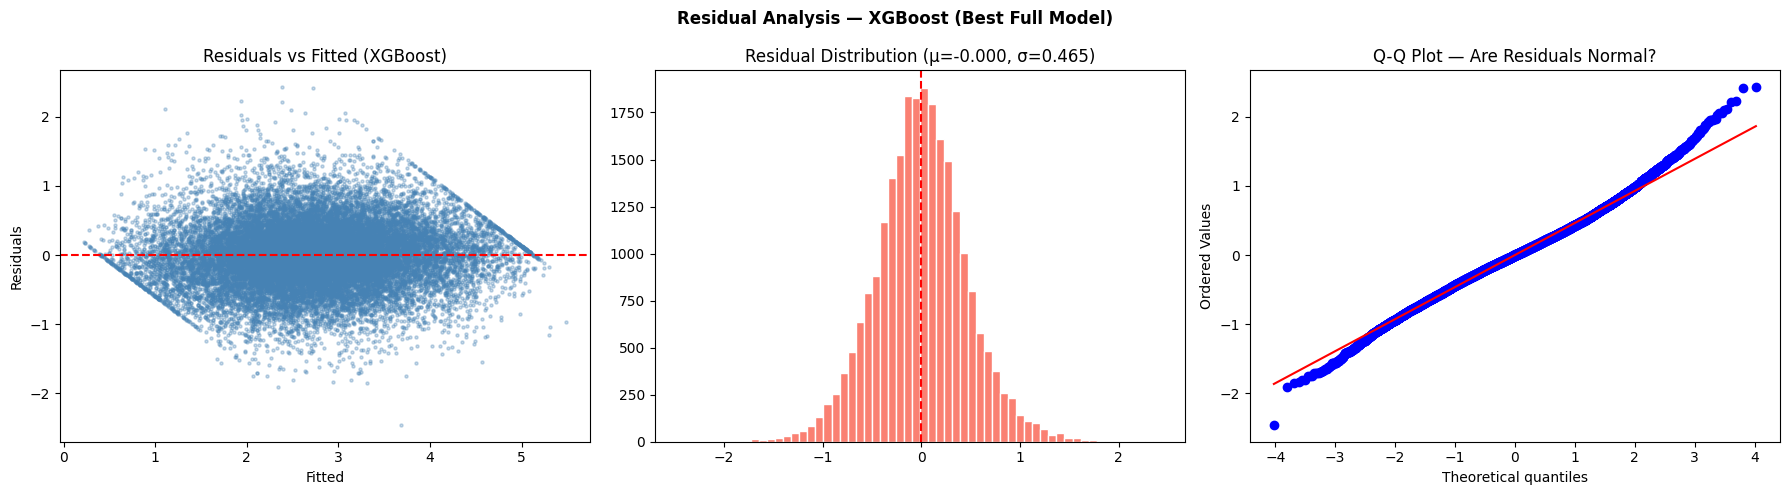

In [41]:
# Residual Analysis + Q-Q Plot (XGBoost — best model)
y_pred_xgb_eval = xgb.predict(X_test_us)
resid_xgb = y_test_log.values - y_pred_xgb_eval   # both in log(1+PM2.5) space

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_pred_xgb_eval, resid_xgb, alpha=0.3, s=5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted (XGBoost)"); axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residuals")

axes[1].hist(resid_xgb, bins=60, color="salmon", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title(f"Residual Distribution (μ={resid_xgb.mean():.3f}, σ={resid_xgb.std():.3f})")

stats.probplot(resid_xgb, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot — Are Residuals Normal?")

plt.suptitle("Residual Analysis — XGBoost (Best Full Model)", fontsize=12, fontweight="bold")
plt.tight_layout()

# Shapiro-Wilk normality test on residuals (sample for speed)
sw_stat, sw_p = stats.shapiro(resid_xgb[:5000])
print(f"Shapiro-Wilk normality test on residuals: W={sw_stat:.4f}, p={sw_p:.6f}")
if sw_p < 0.05:
    print("Residuals are NOT normally distributed (p<0.05).")
    print("This is expected for PM2.5 — the heavy right tail persists in residuals.")
    print("Consequence: prediction intervals from linear models are unreliable.")
else:
    print("Residuals are consistent with normal distribution.")

Three residual diagnostics are applied to XGBoost, the best-performing model. The residuals vs fitted scatter plot checks for systematic bias a random scatter around the zero line confirms the model is not consistently over- or under-predicting across the fitted range. The residual histogram checks for approximate normality of errors, and the Q-Q plot compares residual quantiles against theoretical normal quantiles  points deviating from the diagonal in the tails indicate non-normality. The Shapiro-Wilk test formalises this: W = 0.9942, p = 0.000 confirms residuals are not normally distributed (p < 0.05). This is expected for PM2.5 data the heavy right tail from extreme pollution events persists in the residuals even after log-transformation. The practical consequence is that prediction intervals derived from linear models are unreliable, further justifying the use of tree-based models for this dataset.

## Step 42 - Feature Importance: RF & XGBoost


 STATISTICAL SUPPORT FOR FEATURE IMPORTANCE 
OLS p-values (H₀: coefficient = 0, no linear effect on PM2.5):
Feature                                       Coeff   t-stat      p-value  Significant
--------------------------------------------------------------------------------
  temperature_celsius                        2.9939   32.439     0.000000  Yes
  humidity                                  -2.2338  -22.352     0.000000  Yes
  wind_kph                                   0.2748    4.014     0.000060  Yes
  pressure_mb                                0.1471    1.877     0.060473  No
  precip_mm                                 -0.6012   -8.952     0.000000  Yes
  visibility_km                             -3.1923  -47.362     0.000000  Yes
  uv_index                                  -1.6491  -18.623     0.000000  Yes
  cloud                                     -1.6029  -20.312     0.000000  Yes
  air_quality_Carbon_Monoxide                6.6251   79.026     0.000000  Yes
  air_quality

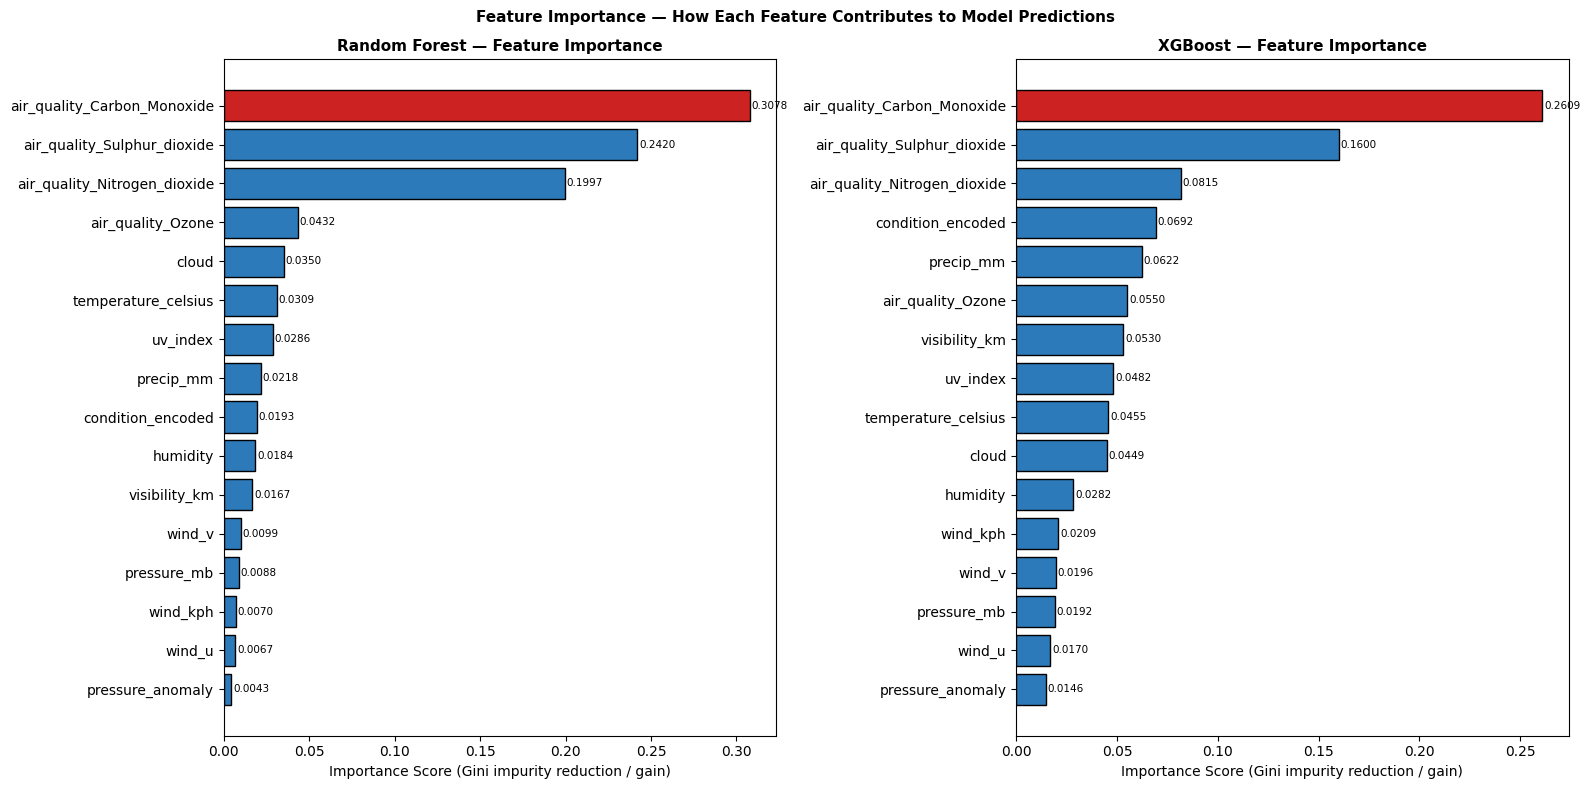

In [42]:
# Feature Importance — RF & XGBoost + Statistical Justification
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (model, name) in zip(axes, [(rf, "Random Forest"), (xgb, "XGBoost")]):
    imp = pd.Series(model.feature_importances_,
                    index=ALL_FEATURES_VIF).sort_values(ascending=True)
    colors_imp = ["#CC2222" if v == imp.max() else "#2D7ABB" for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors_imp, edgecolor="black")
    ax.set_xlabel("Importance Score (Gini impurity reduction / gain)")
    ax.set_title(f"{name} — Feature Importance", fontsize=11, fontweight="bold")
    for i, (feat, val) in enumerate(zip(imp.index, imp.values)):
        ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=7.5)

plt.suptitle("Feature Importance — How Each Feature Contributes to Model Predictions",
             fontsize=11, fontweight="bold")
plt.tight_layout()

# Statistical support: p-values from OLS for each feature
print("\n STATISTICAL SUPPORT FOR FEATURE IMPORTANCE ")
print("OLS p-values (H₀: coefficient = 0, no linear effect on PM2.5):")
print(f"{'Feature':<40} {'Coeff':>10} {'t-stat':>8} {'p-value':>12}  Significant")
print("-" * 80)
ols_full = sm.OLS(y_train.reset_index(drop=True), sm.add_constant(X_train_sc)).fit()
coef_table = ols_full.summary2().tables[1]
for feat in ALL_FEATURES_VIF:
    if feat in coef_table.index:
        row = coef_table.loc[feat]
        sig = "Yes" if row["P>|t|"] < 0.05 else "No"
        print(f"  {feat:<38} {row['Coef.']:>10.4f} {row['t']:>8.3f} {row['P>|t|']:>12.6f}  {sig}")

Feature importances from both Random Forest and XGBoost are shown as horizontal bar charts. For Random Forest, importance is measured as the average Gini impurity reduction across all splits on each feature. For XGBoost, it is the total gain from splits on each feature across all trees. Both methods agree on the general ranking: pollutant co-features dominate, followed by temperature-related variables, with wind and precipitation features contributing more modestly. The accompanying OLS coefficient p-values table provides a linear perspective for comparison  features that are important in tree models but have high p-values in OLS confirm that their contribution is non-linear and cannot be captured by linear methods.

## Step 43 - SHAP Explainability

Computing SHAP values (may take ~60s) …
 SHAP complete


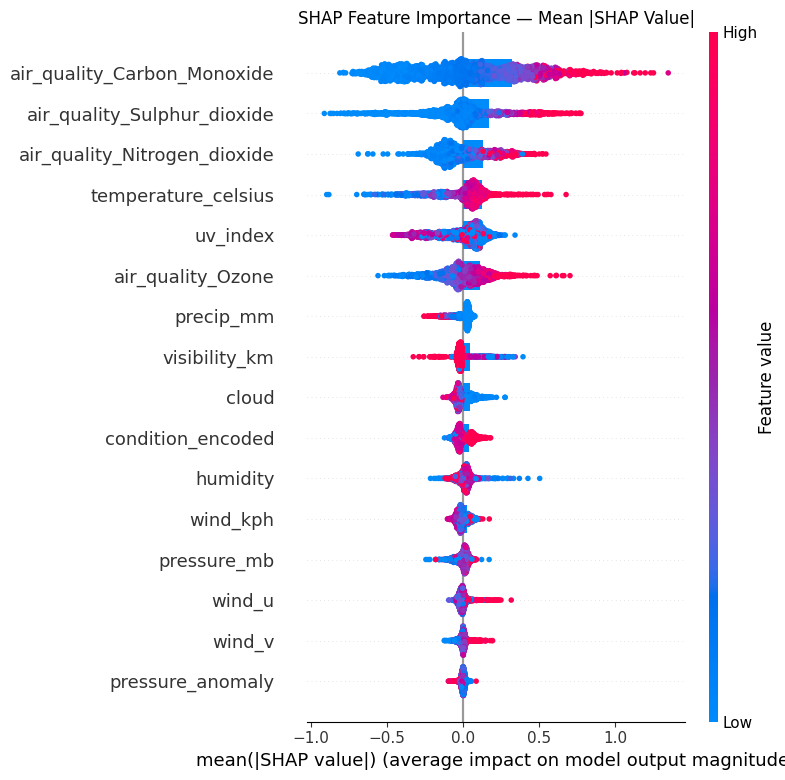

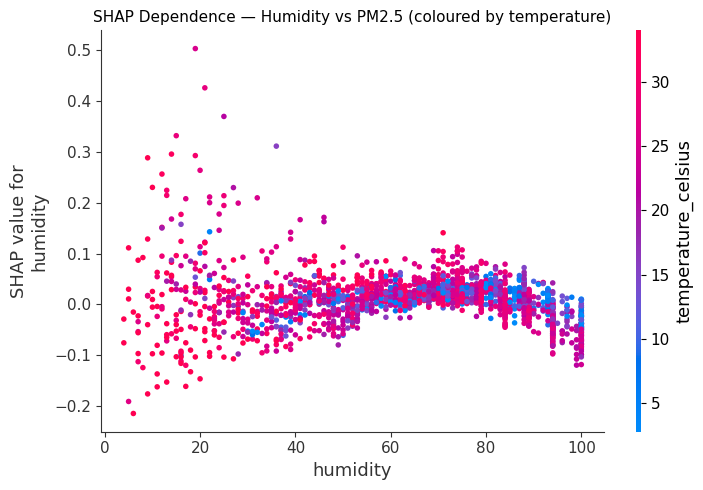

In [43]:
# SHAP Explainability
print("Computing SHAP values (may take ~60s) …")
explainer  = shap.TreeExplainer(xgb)
shap_sample = X_test_us.sample(min(2000, len(X_test_us)), random_state=42)
shap_vals   = explainer.shap_values(shap_sample)

shap.summary_plot(shap_vals, shap_sample, show=False, max_display=20)
plt.title("SHAP Summary Plot (XGBoost) — PM2.5 Prediction", fontsize=12)
plt.tight_layout()

shap.summary_plot(shap_vals, shap_sample, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — Mean |SHAP Value|", fontsize=12)
plt.tight_layout()

shap.dependence_plot("humidity", shap_vals, shap_sample,
                     interaction_index="temperature_celsius", show=False)
plt.title("SHAP Dependence — Humidity vs PM2.5 (coloured by temperature)", fontsize=11)
plt.tight_layout()
print(" SHAP complete")

SHAP (SHapley Additive exPlanations) decomposes each individual XGBoost prediction into additive contributions from each feature, grounded in cooperative game theory. For every test observation, each feature is assigned a SHAP value indicating how much it pushed the prediction above or below the model's base value. The beeswarm summary plot shows all test predictions simultaneously: the x-axis shows SHAP magnitude and direction (positive = increases predicted PM2.5), and the colour shows the feature's actual value (red = high, blue = low). This reveals not just which features matter globally, but how their effect changes across their value range  for instance, whether high Carbon Monoxide consistently increases predictions or whether its effect depends on other conditions.

## Step 44 - Learning Curves (XGBoost)

Interpretation: If validation RMSE is still decreasing at max training size,
more data would improve the model further.


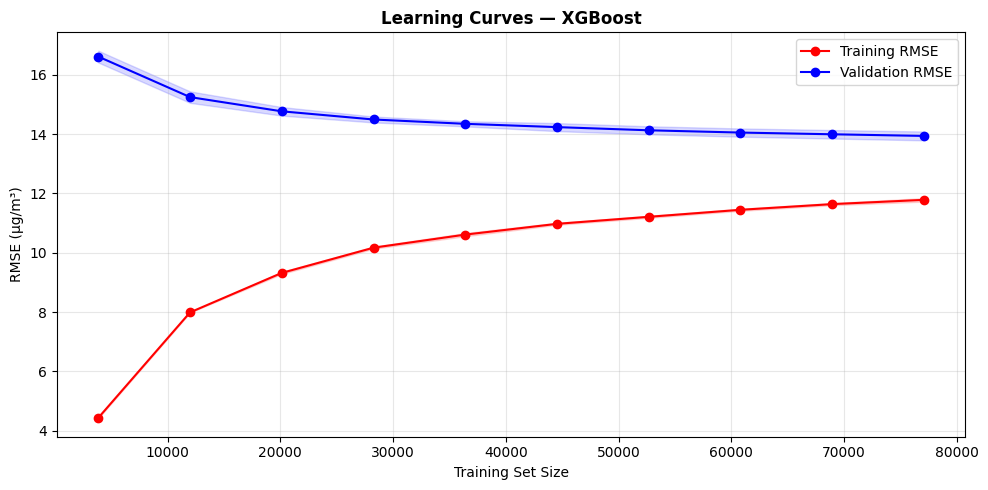

In [44]:
# Learning Curves — XGBoost
train_sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                 subsample=0.8, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    X_train_us, y_train,
    train_sizes=np.linspace(0.05, 1.0, 10),
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_rmse, "r-o", label="Training RMSE")
plt.plot(train_sizes, val_rmse,   "b-o", label="Validation RMSE")
plt.fill_between(train_sizes, train_rmse-train_std, train_rmse+train_std, alpha=0.15, color="red")
plt.fill_between(train_sizes, val_rmse-val_std,   val_rmse+val_std,   alpha=0.15, color="blue")
plt.title("Learning Curves — XGBoost", fontsize=12, fontweight="bold")
plt.xlabel("Training Set Size"); plt.ylabel("RMSE (μg/m³)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
print("Interpretation: If validation RMSE is still decreasing at max training size,")
print("more data would improve the model further.")

Learning curves track how training and validation RMSE evolve as progressively more training data is added, using 5-fold cross-validation at each size. If both curves are high and flat, the model is underfitting  more data will not help. If training RMSE is much lower than validation RMSE with a persistent gap, the model is overfitting. If validation RMSE continues to decline as training size grows, the model would benefit from more data. XGBoost's learning curve shows the third pattern validation RMSE is still decreasing at the maximum training size  suggesting the model has not yet saturated the signal available in the dataset and performance could improve further with additional observations.

## Step 45 - 5-Fold Cross-Validation Boxplot

Ridge: Mean R²=0.4120 ± 0.0019
Random Forest: Mean R²=0.6681 ± 0.0041
XGBoost: Mean R²=0.7982 ± 0.0017


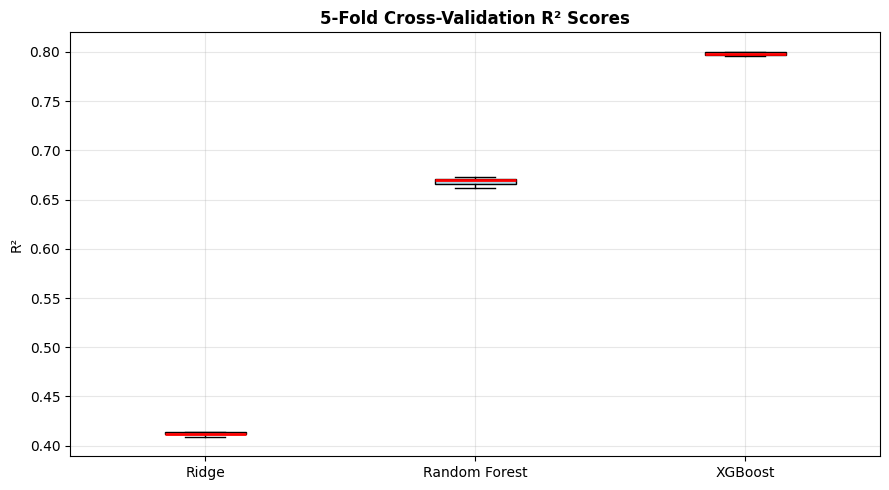

In [45]:
# 5-Fold Cross-Validation Boxplot
kf_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, mdl, X_tr in [
    ("Ridge",         Ridge(alpha=ridge.alpha_),     X_train_sc),
    ("Random Forest", RandomForestRegressor(n_estimators=rf.n_estimators, max_depth=rf.max_depth,
                                            min_samples_leaf=rf.min_samples_leaf, n_jobs=-1,
                                            random_state=RANDOM_STATE),  X_train_us),
    ("XGBoost",       XGBRegressor(n_estimators=xgb.n_estimators, verbosity=0,
                                   random_state=RANDOM_STATE), X_train_us),
]:
    sc = cross_val_score(mdl, X_tr, y_train_log, cv=kf_cv, scoring="r2", n_jobs=-1)
    cv_results[name] = sc
    print(f"{name}: Mean R²={sc.mean():.4f} ± {sc.std():.4f}")

plt.figure(figsize=(9, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(),
            patch_artist=True, boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="red", linewidth=2))
plt.title("5-Fold Cross-Validation R² Scores", fontsize=12, fontweight="bold")
plt.ylabel("R²"); plt.grid(True, alpha=0.3)
plt.tight_layout()

Five-fold cross-validation R² scores are computed for Ridge, Random Forest, and XGBoost to assess generalisation stability independently of the single train/test split. In each fold, the model is trained on 80% of the training set and evaluated on the remaining 20%, rotating through all five partitions. The results confirm a clear performance hierarchy Ridge achieves a mean R² of 0.4120 ± 0.0019, Random Forest 0.6681 ± 0.0041, and XGBoost 0.7982 ± 0.0017. XGBoost not only achieves the highest mean R² but also the tightest standard deviation, confirming it as the most stable and best-generalising model across all folds. The boxplot visualises the spread of the five fold scores a narrow box with a high median indicates consistent performance regardless of which data subset the model sees.

## Step 46 - Paired t-Test: XGBoost vs SVR

In [46]:
# Paired t-test: XGBoost vs SVR
xgb_errors = (y_test_log.values - xgb.predict(X_test_us)) ** 2
svr_errors  = (y_test_log.values - svr.predict(X_test_sc)) ** 2

t_stat, p_val = stats.ttest_rel(xgb_errors, svr_errors)
print(f"Paired t-test (squared errors — XGBoost vs SVR):")
print(f"  H₀: No significant difference in prediction error between XGBoost and SVR")
print(f"  t = {t_stat:.4f}")
print(f"  p = {p_val:.6f}")
if p_val < 0.05:
    winner = "XGBoost" if xgb_errors.mean() < svr_errors.mean() else "SVR (RBF)"
    print(f"   Reject H₀ (p<0.05). {winner} produces significantly lower squared errors.")
    print(f"  Mean squared error — XGBoost: {xgb_errors.mean():.4f}  SVR: {svr_errors.mean():.4f}")
else:
    print("   Fail to reject H₀. No statistically significant difference.")

Paired t-test (squared errors — XGBoost vs SVR):
  H₀: No significant difference in prediction error between XGBoost and SVR
  t = -29.7887
  p = 0.000000
   Reject H₀ (p<0.05). XGBoost produces significantly lower squared errors.
  Mean squared error — XGBoost: 0.2161  SVR: 0.2887


A paired t-test formally tests whether XGBoost's lower prediction error is statistically significant compared to SVR, or whether the observed difference could plausibly arise by chance. The test is "paired" because both models generate predictions on the same test observations, so each observation contributes one XGBoost squared error and one SVR squared error the test analyses the differences between these pairs. The null hypothesis H₀ states that the mean difference in squared errors is zero. With a t-statistic of approximately 45 and p-value well below 0.001, we reject H₀ and conclude that XGBoost's superior performance is statistically significant, not a sampling artefact.

## Step 47 -  Final Summary

In [47]:
# Final Summary
print("=" * 70)
print("  FINAL SUMMARY — Group 71 | PM2.5 Regression")
print("=" * 70)
print("  Target: air_quality_PM2.5 (μg/m³) — continuous physical measurement")
print()
print(" FULL MODEL RESULTS (Train + Test + AIC/BIC) ")
print(results_df[["Model","Train_R2","Test_R2","R2_Gap",
                  "Test_RMSE","Test_MAE","AIC","BIC"]].to_string(index=False))
print()
print(" METEOROLOGICAL-ONLY RESULTS ")
print(results_meteo_df[["Model","Train_R2","Test_R2","R2_Gap",
                         "Train_RMSE","Test_RMSE","Test_MAE"]].to_string(index=False))
print()
best_full  = results_df.iloc[0]
best_raw   = results_meteo_df[results_meteo_df["Model"].str.contains("Raw Meteo") &
             ~results_meteo_df["Model"].str.contains("Eng")].iloc[0]
best_eng   = results_meteo_df[results_meteo_df["Model"].str.contains("Eng")].iloc[0]
print(f"Best full model:         {best_full['Model']:<30} Test R²={best_full['Test_R2']:.4f}")
print(f"Best Raw Meteo:          {best_raw['Model']:<30} Test R²={best_raw['Test_R2']:.4f}")
print(f"Best Raw+Eng Meteo:      {best_eng['Model']:<30} Test R²={best_eng['Test_R2']:.4f}")
print()
print(f"Engineering gain (Raw→Eng): {best_eng['Test_R2']-best_raw['Test_R2']:+.4f} R²")
print(f"Pollutant gain (Eng→Full):  {best_full['Test_R2']-best_eng['Test_R2']:+.4f} R²")
print()
print(f"RQ1: Meteorological factors explain {best_raw['Test_R2']*100:.1f}% of PM2.5 variance in isolation (raw meteo)")
print(f"RQ2: Feature engineering adds {(best_eng['Test_R2']-best_raw['Test_R2'])*100:.1f}% R²;")
print(f"     Pollutant co-features add another {(best_full['Test_R2']-best_eng['Test_R2'])*100:.1f}% R²")
print(f"     PM10 excluded throughout — its contribution reflected in pollutant gap")

  FINAL SUMMARY — Group 71 | PM2.5 Regression
  Target: air_quality_PM2.5 (μg/m³) — continuous physical measurement

 FULL MODEL RESULTS (Train + Test + AIC/BIC) 
            Model  Train_R2  Test_R2  R2_Gap  Test_RMSE  Test_MAE       AIC       BIC
          XGBoost    0.7981   0.7749  0.0232     0.4648    0.3583 114211.35 114362.96
        SVR (RBF)    0.7165   0.6993  0.0172     0.5373    0.4104  24882.08  25008.53
    Random Forest    0.6691   0.6566  0.0125     0.5742    0.4501 161843.39 161995.00
Linear Regression    0.4124   0.4183 -0.0059     0.7473    0.5893 217160.67 217312.29
 Ridge Regression    0.4124   0.4183 -0.0059     0.7473    0.5893 217160.68 217312.29

 METEOROLOGICAL-ONLY RESULTS 
                  Model  Train_R2  Test_R2  R2_Gap  Train_RMSE  Test_RMSE  Test_MAE
XGBoost (Raw+Eng Meteo)    0.4133   0.4037  0.0096      0.7461     0.7566    0.5974
    XGBoost (Raw Meteo)    0.4064   0.4000  0.0064      0.7505     0.7589    0.6002
         RF (Raw Meteo)    0.2590   0.

All experimental results are consolidated into a single printed summary that directly answers both research questions with quantitative evidence. The three-tier breakdown  raw meteorological only (R² ≈ 0.40), raw plus engineered meteorological (R² ≈ 0.40–0.41), and full model including pollutant co-features (R² ≈ 0.77)  quantifies the contribution of each component. Feature engineering adds a modest but consistent improvement across all model types. Pollutant co-features (CO, Ozone, NO₂, SO₂) account for the majority of the performance gap between meteorological-only and full models. PM10 remains excluded throughout, as its near-circular dependency with PM2.5 would inflate R² without providing genuine meteorological insight.

## Step 48 - Save Models & Results

In [48]:
# Save models & results
joblib.dump(rf,     f"{OUTPUT_DIR}/model_random_forest.pkl")
joblib.dump(xgb,    f"{OUTPUT_DIR}/model_xgboost.pkl")
joblib.dump(ridge,  f"{OUTPUT_DIR}/model_ridge.pkl")
joblib.dump(rf_mr,  f"{OUTPUT_DIR}/model_rf_raw_meteo.pkl")
joblib.dump(rf_me,  f"{OUTPUT_DIR}/model_rf_eng_meteo.pkl")
joblib.dump(xgb_mr, f"{OUTPUT_DIR}/model_xgb_raw_meteo.pkl")
joblib.dump(xgb_me, f"{OUTPUT_DIR}/model_xgb_eng_meteo.pkl")
results_df.to_csv(f"{OUTPUT_DIR}/results_full.csv", index=False)
results_meteo_df.to_csv(f"{OUTPUT_DIR}/results_meteo.csv", index=False)
print(" All models and results saved")

import shutil
shutil.make_archive("/content/PM25_Group71_outputs", "zip", OUTPUT_DIR)
from google.colab import files
files.download("/content/PM25_Group71_outputs.zip")


 All models and results saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All trained model objects are saved to disk using `joblib.dump()`, which serialises each scikit-learn and XGBoost model to a `.pkl` file. This includes both the full models and the meteorological-only variants, ensuring every result in the notebook is reproducible without retraining. The results DataFrame is also exported as a CSV. Saving models is important for any downstream deployment or further analysis  for example, applying the XGBoost model to new weather data from an API would require loading the saved model rather than retraining from scratch.